# EDA complète — fraude automobile `carclaims`

Ce notebook réalise une exploration exhaustive et reproductible du jeu `fraud_oracle.csv` avant le feature engineering et la modélisation non supervisée par Isolation Forest.

**Principes :** la cible `FraudFound_P` sert uniquement à comprendre et évaluer les données, jamais à entraîner Isolation Forest ; les identifiants sont isolés ; les catégories ordinales et temporelles sont examinées avant tout encodage.

## 0. Imports et configuration

In [1]:
from pathlib import Path
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from scipy.stats import chi2_contingency, pointbiserialr
from sklearn.feature_selection import mutual_info_classif

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 150)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
sns.set_theme(style='whitegrid', context='notebook', font_scale=1.12)
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#F8FAFC',
    'axes.edgecolor': '#CBD5E1', 'axes.labelcolor': '#0F172A',
    'axes.titlecolor': '#0F172A', 'axes.titleweight': 'bold',
    'axes.titlesize': 14, 'axes.labelsize': 11,
    'xtick.color': '#334155', 'ytick.color': '#334155',
    'grid.color': '#E2E8F0', 'grid.alpha': .75,
    'legend.frameon': False, 'figure.dpi': 115,
})
NAVY, BLUE, TEAL, CORAL, GOLD = '#0F172A', '#2563EB', '#0D9488', '#F43F5E', '#F59E0B'
PALETTE = [BLUE, CORAL]
TARGET = 'FraudFound_P'
RANDOM_STATE = 42

## 1. Chargement robuste et dictionnaire des variables

In [2]:
candidates = [
    Path('../data/raw/fraud_oracle.csv'),
    Path('data/raw/fraud_oracle.csv'),
    Path('../fraud_oracle.csv'),
]
DATA_PATH = next((p.resolve() for p in candidates if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError('fraud_oracle.csv introuvable. Lancer le notebook depuis la racine ou notebooks/.')

df = pd.read_csv(DATA_PATH)
# Normalisation explicite des types critiques pour garantir un résultat stable.
df[TARGET] = pd.to_numeric(df[TARGET], errors='raise').astype('int8')
for c in ['WeekOfMonth', 'WeekOfMonthClaimed', 'Age', 'PolicyNumber', 'RepNumber', 'Deductible', 'DriverRating', 'Year']:
    df[c] = pd.to_numeric(df[c], errors='raise')
print(f'Fichier : {DATA_PATH}')
print(f'Dimensions : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
display(df.head())

Fichier : C:\Users\hamid\Downloads\Projet_ML_iForest\data\raw\fraud_oracle.csv
Dimensions : 15,420 lignes × 33 colonnes


,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,Age,Fault,PolicyType,VehicleCategory,VehiclePrice,FraudFound_P,PolicyNumber,RepNumber,Deductible,DriverRating,Days_Policy_Accident,Days_Policy_Claim,PastNumberOfClaims,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,21,Policy Holder,Sport - Liability,Sport,more than 69000,0,1,12,300,1,more than 30,more than 30,none,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,34,Policy Holder,Sport - Collision,Sport,more than 69000,0,2,15,400,4,more than 30,more than 30,none,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,47,Policy Holder,Sport - Collision,Sport,more than 69000,0,3,7,400,3,more than 30,more than 30,1,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,65,Third Party,Sedan - Liability,Sport,20000 to 29000,0,4,4,400,2,more than 30,more than 30,1,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,27,Third Party,Sport - Collision,Sport,more than 69000,0,5,3,400,1,more than 30,more than 30,none,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


In [3]:
variable_roles = {
    'cible_evaluation': [TARGET],
    'identifiant': ['PolicyNumber'],
    'temporelles': ['Month', 'WeekOfMonth', 'DayOfWeek', 'DayOfWeekClaimed', 'MonthClaimed', 'WeekOfMonthClaimed', 'Year'],
    'numeriques': ['Age', 'Deductible', 'DriverRating', 'RepNumber'],
    'ordinales': ['VehiclePrice', 'Days_Policy_Accident', 'Days_Policy_Claim', 'PastNumberOfClaims',
                  'AgeOfVehicle', 'AgeOfPolicyHolder', 'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars'],
}
assigned = set(sum(variable_roles.values(), []))
variable_roles['nominales'] = [c for c in df.columns if c not in assigned]
for role, cols in variable_roles.items():
    print(f'{role:18s} ({len(cols):2d}) : {cols}')

cible_evaluation   ( 1) : ['FraudFound_P']
identifiant        ( 1) : ['PolicyNumber']
temporelles        ( 7) : ['Month', 'WeekOfMonth', 'DayOfWeek', 'DayOfWeekClaimed', 'MonthClaimed', 'WeekOfMonthClaimed', 'Year']
numeriques         ( 4) : ['Age', 'Deductible', 'DriverRating', 'RepNumber']
ordinales          ( 9) : ['VehiclePrice', 'Days_Policy_Accident', 'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder', 'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars']
nominales          (11) : ['Make', 'AccidentArea', 'Sex', 'MaritalStatus', 'Fault', 'PolicyType', 'VehicleCategory', 'PoliceReportFiled', 'WitnessPresent', 'AgentType', 'BasePolicy']


## 2. Audit de qualité

On vérifie les types, valeurs manquantes explicites ou déguisées, doublons, unicité, constantes, modalités rares et validité de la cible.

In [4]:
quality = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'n_missing': df.isna().sum(),
    'pct_missing': 100 * df.isna().mean(),
    'n_unique': df.nunique(dropna=False),
    'pct_unique': 100 * df.nunique(dropna=False) / len(df),
}).sort_values(['n_missing', 'n_unique'], ascending=[False, True])
display(quality)

# `none` est une modalité métier valide ici (aucun antécédent/supplément/délai), pas une valeur manquante.
missing_tokens = {'', ' ', '?', 'na', 'n/a', 'nan', 'null', 'unknown'}
disguised = {}
for c in df.select_dtypes(include='object'):
    normalized = df[c].astype(str).str.strip().str.lower()
    count = normalized.isin(missing_tokens).sum()
    if count:
        disguised[c] = int(count)
print('Valeurs manquantes déguisées :', disguised or 'aucune détectée')
print('Lignes entièrement dupliquées :', df.duplicated().sum())
print('PolicyNumber unique :', df['PolicyNumber'].is_unique)
print('Valeurs de la cible :', sorted(df[TARGET].unique()))

,dtype,n_missing,pct_missing,n_unique,pct_unique
AccidentArea,str,0,0.000,2,0.013
Sex,str,0,0.000,2,0.013
Fault,str,0,0.000,2,0.013
FraudFound_P,int8,0,0.000,2,0.013
PoliceReportFiled,str,0,0.000,2,0.013
WitnessPresent,str,0,0.000,2,0.013
AgentType,str,0,0.000,2,0.013
VehicleCategory,str,0,0.000,3,0.019
Year,int64,0,0.000,3,0.019
BasePolicy,str,0,0.000,3,0.019


Valeurs manquantes déguisées : aucune détectée
Lignes entièrement dupliquées : 0
PolicyNumber unique : True
Valeurs de la cible : [np.int8(0), np.int8(1)]


In [5]:
duplicate_without_id = df.drop(columns=['PolicyNumber']).duplicated(keep=False)
print(f'Lignes dupliquées hors identifiant : {duplicate_without_id.sum():,}')
if duplicate_without_id.any():
    display(df.loc[duplicate_without_id].sort_values(list(df.columns.difference(['PolicyNumber']))).head(20))

rare_rows = []
for c in df.select_dtypes(exclude='number').columns:
    counts = df[c].value_counts(dropna=False)
    rare_rows.append({
        'variable': c, 'modalites': len(counts),
        'modalites_1pct': int((counts < .01 * len(df)).sum()),
        'modalites_50obs': int((counts < 50).sum()),
        'part_modalite_majoritaire': counts.iloc[0] / len(df)
    })
rare_summary = pd.DataFrame(rare_rows).sort_values(['modalites_1pct', 'modalites'], ascending=False)
display(rare_summary)

Lignes dupliquées hors identifiant : 0


,variable,modalites,modalites_1pct,modalites_50obs,part_modalite_majoritaire
2,Make,19,11,7,0.249
9,PolicyType,9,4,4,0.362
12,Days_Policy_Accident,5,4,2,0.989
4,DayOfWeekClaimed,8,3,1,0.244
13,Days_Policy_Claim,4,3,2,0.995
16,AgeOfPolicyHolder,9,2,1,0.363
15,AgeOfVehicle,8,2,0,0.377
22,NumberOfCars,5,2,2,0.928
7,MaritalStatus,4,2,1,0.689
5,MonthClaimed,13,1,1,0.094


### Interprétation - qualité des données

- Les **15 420 dossiers sont uniques**, même sans `PolicyNumber` : aucun doublon ne doit être supprimé.
- `PolicyNumber` est unique à 100 % : c'est un identifiant pur à exclure.
- Il n'existe aucune valeur manquante native. `none` est une modalité métier valide, pas une absence de donnée.
- Une ligne contient néanmoins le code invalide `0` pour le mois et le jour de déclaration. Il faudra le recoder en `Unknown`.
- Les modalités rares ne seront regroupées qu'après le découpage train/test afin d'éviter toute fuite d'information.

## 3. Variable cible et déséquilibre

En fraude, l'accuracy est trompeuse. L'EDA quantifie le taux de fraude et fixe les futures métriques : ROC-AUC, PR-AUC, rappel et précision dans les dossiers les mieux scorés.

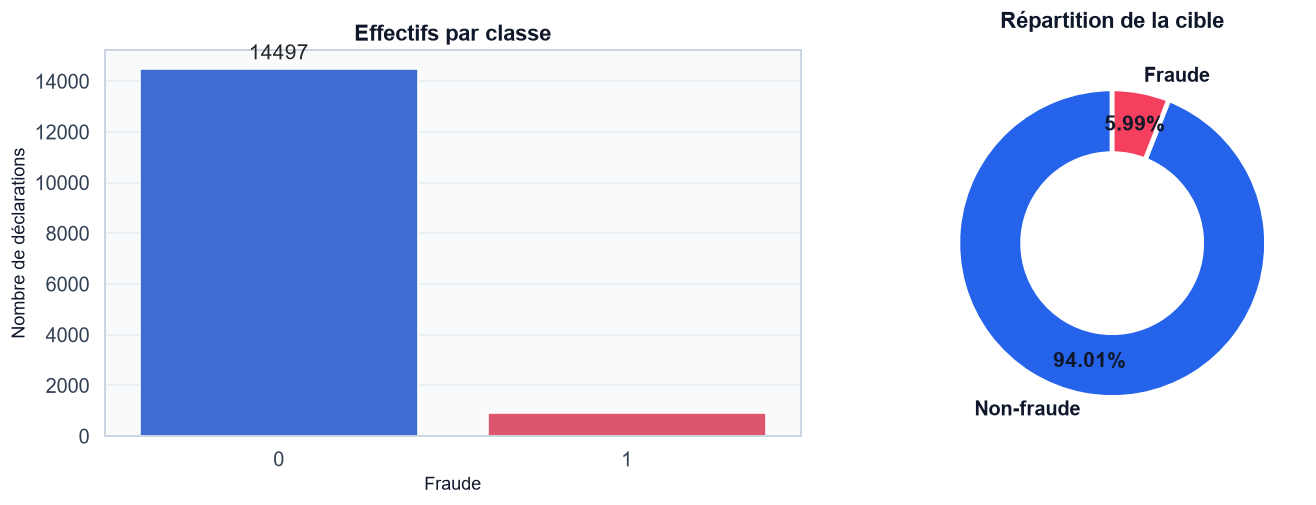

In [6]:
target_counts = df[TARGET].value_counts().sort_index()
target_labels = target_counts.rename({0: 'Non-fraude', 1: 'Fraude'})

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
sns.countplot(data=df, x=TARGET, hue=TARGET, palette=PALETTE, legend=False, ax=axes[0])
axes[0].bar_label(axes[0].containers[0], padding=3)
axes[0].set(title='Effectifs par classe', xlabel='Fraude', ylabel='Nombre de déclarations')
axes[1].pie(target_labels, labels=target_labels.index, autopct='%1.2f%%', colors=PALETTE, startangle=90, pctdistance=.78, wedgeprops={'width': .42, 'edgecolor': 'white', 'linewidth': 3}, textprops={'color': NAVY, 'weight': 'bold'})
axes[1].set_title('Répartition de la cible', pad=14)
plt.tight_layout()
plt.show()

### Interprétation - variable cible

La base contient **923 fraudes, soit 5,99 %**. Un modèle prédisant toujours « non-fraude » obtiendrait déjà 94,01 % d'accuracy : cette métrique est donc trompeuse. Les métriques principales seront PR-AUC, ROC-AUC, rappel, précision@k et lift@k. `FraudFound_P` sera exclue de l'entraînement d'Isolation Forest et utilisée uniquement pour l'évaluation.

## 4. Analyse univariée des variables numériques

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
WeekOfMonth,"15,420.000",2.789,1.288,1.000,1.000,1.000,2.000,3.000,4.000,5.000,5.000,5.000
WeekOfMonthClaimed,"15,420.000",2.694,1.259,1.000,1.000,1.000,2.000,3.000,4.000,5.000,5.000,5.000
Age,"15,420.000",39.856,13.492,0.000,0.000,23.000,31.000,38.000,48.000,64.000,76.000,80.000
RepNumber,"15,420.000",8.483,4.600,1.000,1.000,1.000,5.000,8.000,12.000,16.000,16.000,16.000
Deductible,"15,420.000",407.704,43.951,300.000,400.000,400.000,400.000,400.000,400.000,400.000,700.000,700.000
DriverRating,"15,420.000",2.488,1.119,1.000,1.000,1.000,1.000,2.000,3.000,4.000,4.000,4.000
Year,"15,420.000","1,994.866",0.803,"1,994.000","1,994.000","1,994.000","1,994.000","1,995.000","1,996.000","1,996.000","1,996.000","1,996.000"


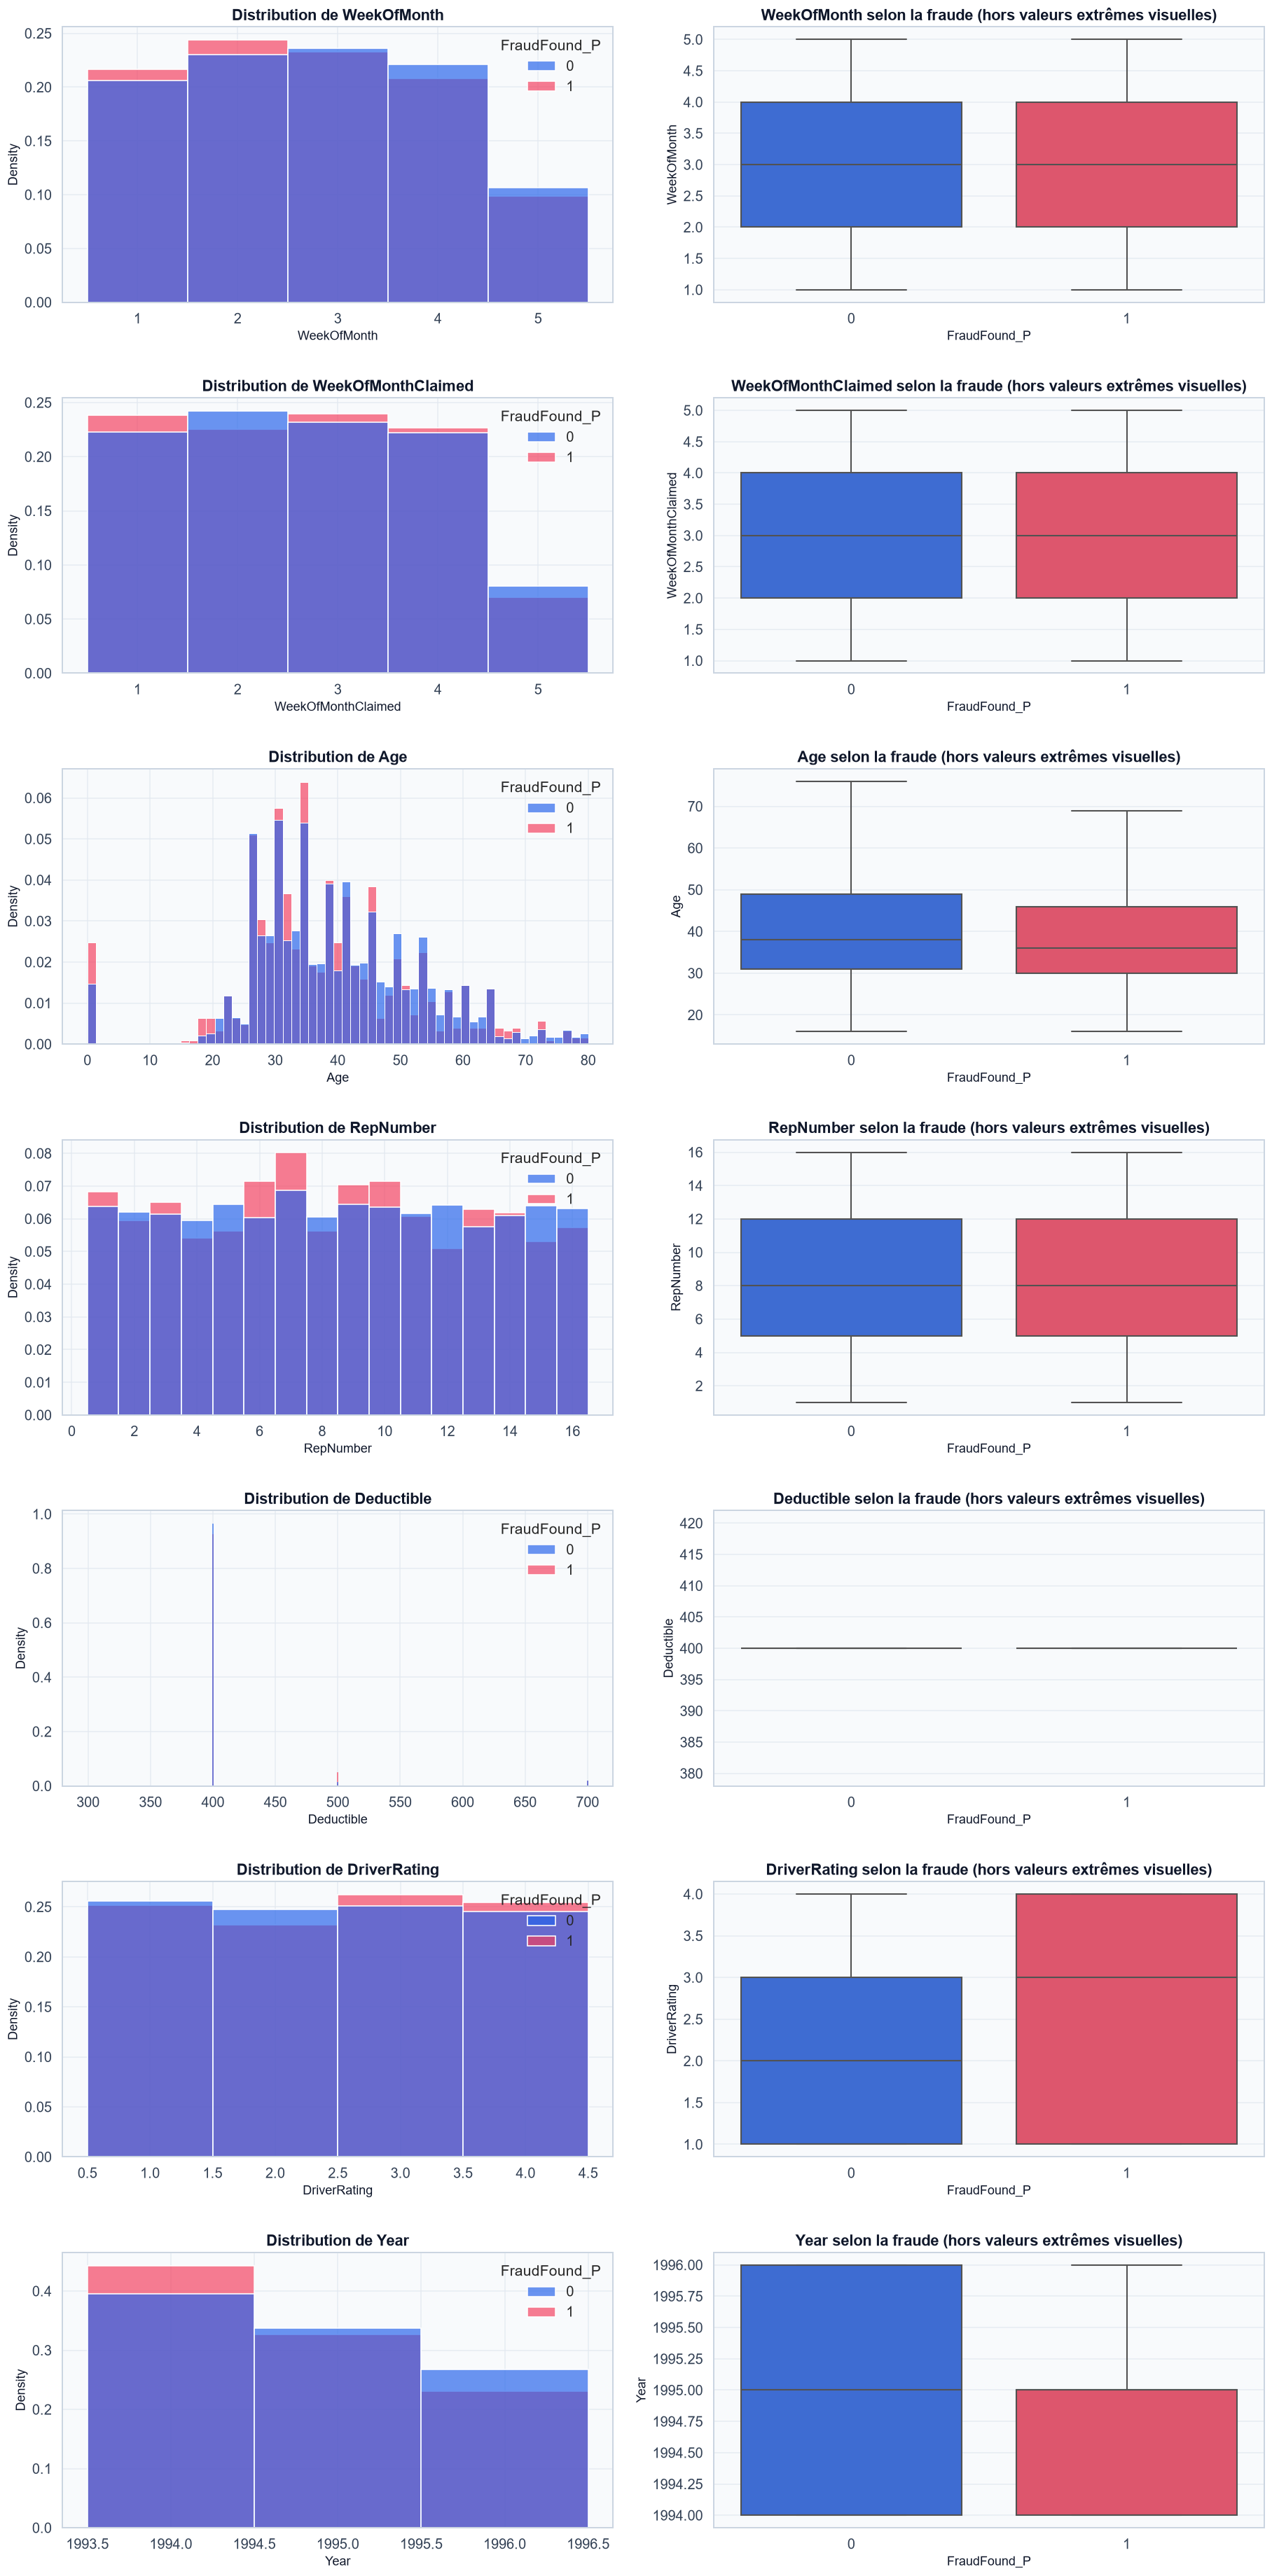

In [7]:
numeric_cols = [c for c in df.select_dtypes(include=np.number).columns if c not in [TARGET, 'PolicyNumber']]
display(df[numeric_cols].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T)

fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(16, 4.6 * len(numeric_cols)))
axes = np.atleast_2d(axes)
for i, c in enumerate(numeric_cols):
    sns.histplot(data=df, x=c, hue=TARGET, stat='density', common_norm=False, discrete=df[c].nunique() < 20, ax=axes[i, 0], palette=PALETTE, alpha=.68)
    axes[i, 0].set_title(f'Distribution de {c}')
    sns.boxplot(data=df, x=TARGET, y=c, palette=PALETTE, showfliers=False, linewidth=1.3, ax=axes[i, 1])
    axes[i, 1].set_title(f'{c} selon la fraude (hors valeurs extrêmes visuelles)')
plt.tight_layout(h_pad=2.4, w_pad=2.0)
plt.show()

In [8]:
num_target_rows = []
for c in numeric_cols:
    clean = df[[c, TARGET]].dropna()
    r, p = pointbiserialr(clean[TARGET], clean[c])
    num_target_rows.append({
        'variable': c, 'moyenne_non_fraude': clean.loc[clean[TARGET].eq(0), c].mean(),
        'moyenne_fraude': clean.loc[clean[TARGET].eq(1), c].mean(),
        'correlation_point_biserial': r, 'p_value': p
    })
display(pd.DataFrame(num_target_rows).sort_values('correlation_point_biserial', key=abs, ascending=False))

,variable,moyenne_non_fraude,moyenne_fraude,correlation_point_biserial,p_value
2,Age,39.957,38.265,-0.030,0.000
6,Year,"1,994.871","1,994.788",-0.025,0.002
4,Deductible,407.512,410.726,0.017,0.031
0,WeekOfMonth,2.792,2.728,-0.012,0.141
3,RepNumber,8.492,8.346,-0.008,0.348
5,DriverRating,2.486,2.520,0.007,0.367
1,WeekOfMonthClaimed,2.696,2.665,-0.006,0.474


In [9]:
# Les dossiers Age == 0 coïncident-ils avec une catégorie identifiée de AgeOfPolicyHolder ?
age0 = df['Age'].eq(0)
print(f"Age == 0 : {age0.sum()} dossiers ({age0.mean():.2%})")
display(df.loc[age0, 'AgeOfPolicyHolder'].value_counts().to_frame('effectif'))
print(f"Taux de fraude parmi Age == 0 : {df.loc[age0, TARGET].mean():.2%} "
      f"(global : {df[TARGET].mean():.2%})")

Age == 0 : 320 dossiers (2.08%)


,effectif
AgeOfPolicyHolder,
16 to 17,320


Taux de fraude parmi Age == 0 : 9.69% (global : 5.99%)


### Interprétation - variables numériques

- Toutes les corrélations point-bisériales ont une valeur absolue inférieure à **0,03** : aucun prédicteur numérique brut ne sépare seul correctement les fraudes.
- L'âge moyen est légèrement plus faible chez les fraudes, mais l'effet est petit malgré sa significativité statistique.
- `RepNumber`, `DriverRating`, les semaines et l'année ont très peu de signal univarié; leur utilité éventuelle sera non linéaire ou interactionnelle.
- Les 320 dossiers `Age == 0` (2,08 %) correspondent **exactement** aux 320 dossiers `AgeOfPolicyHolder == '16 to 17'` : ce n'est donc pas une valeur manquante aléatoire mais une convention de saisie systématique pour cette tranche. Leur taux de fraude (9,7 %) dépasse le taux global (6,0 %), ce qui justifie un indicateur dédié plutôt qu'une imputation par la moyenne.
- `Deductible` étant presque toujours égal à 400, la règle IQR classique n'est pas pertinente pour cette variable.

## 5. Analyse exhaustive des variables catégorielles et ordinales

Pour chaque modalité : effectif, nombre de fraudes, taux de fraude, lift par rapport au taux global et intervalle de confiance de Wilson. Les petits effectifs sont explicitement signalés.

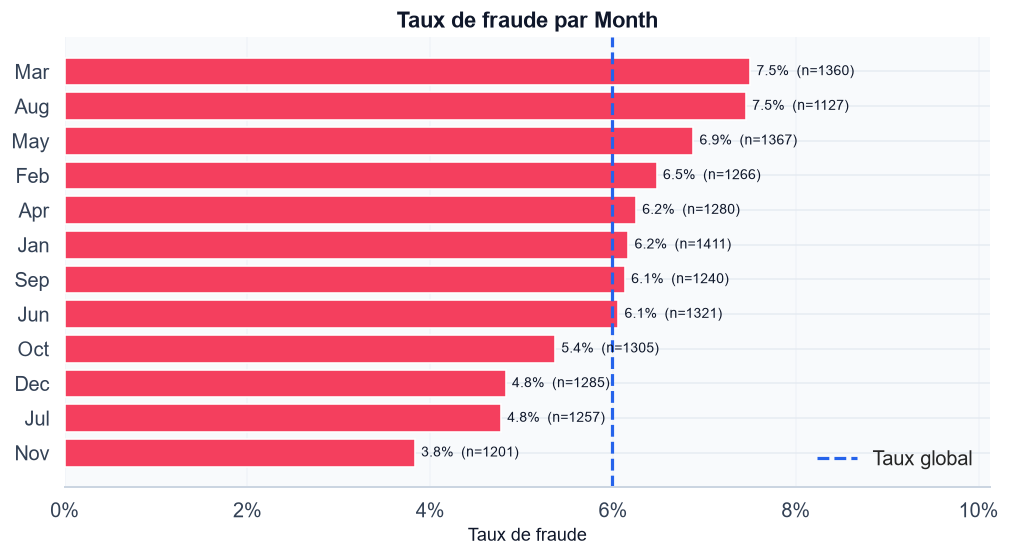

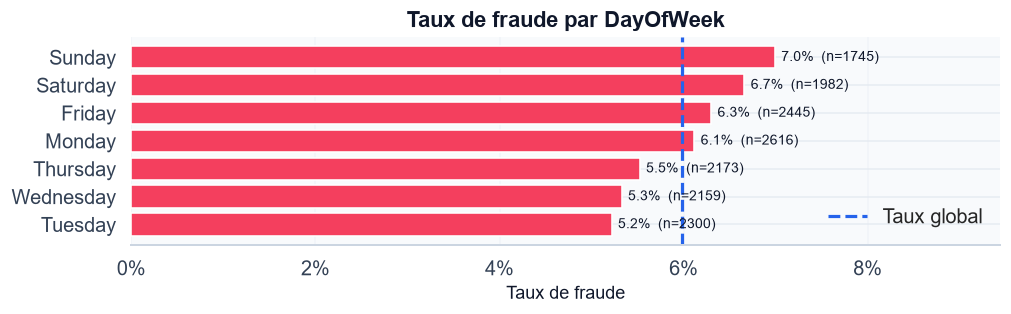

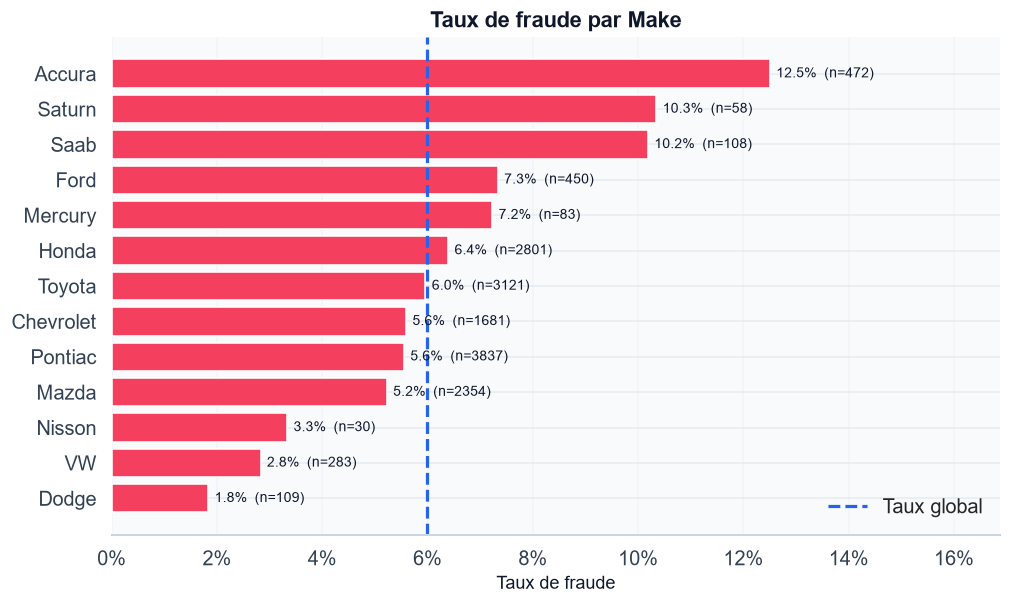

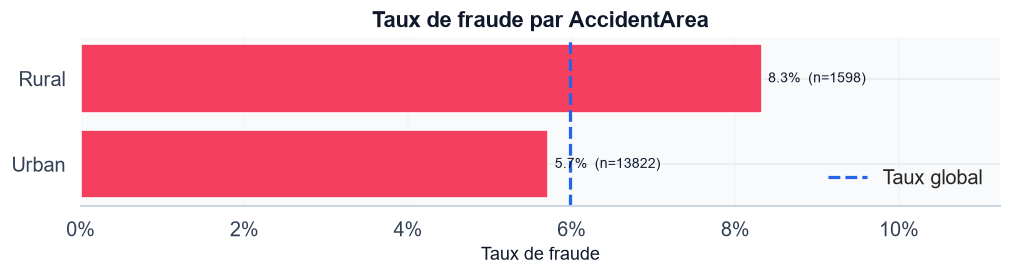

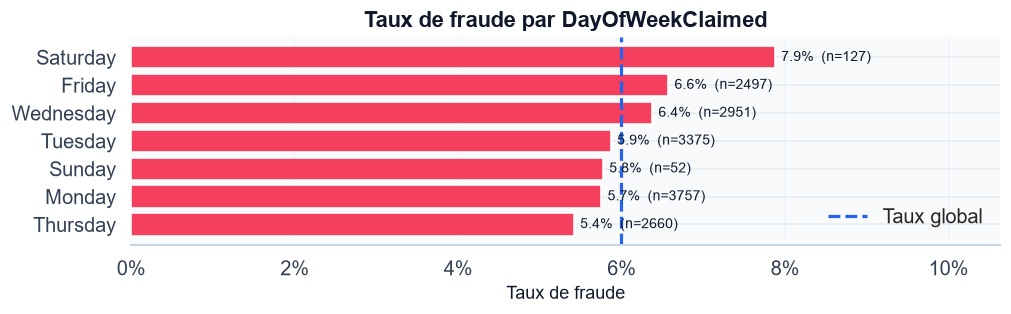

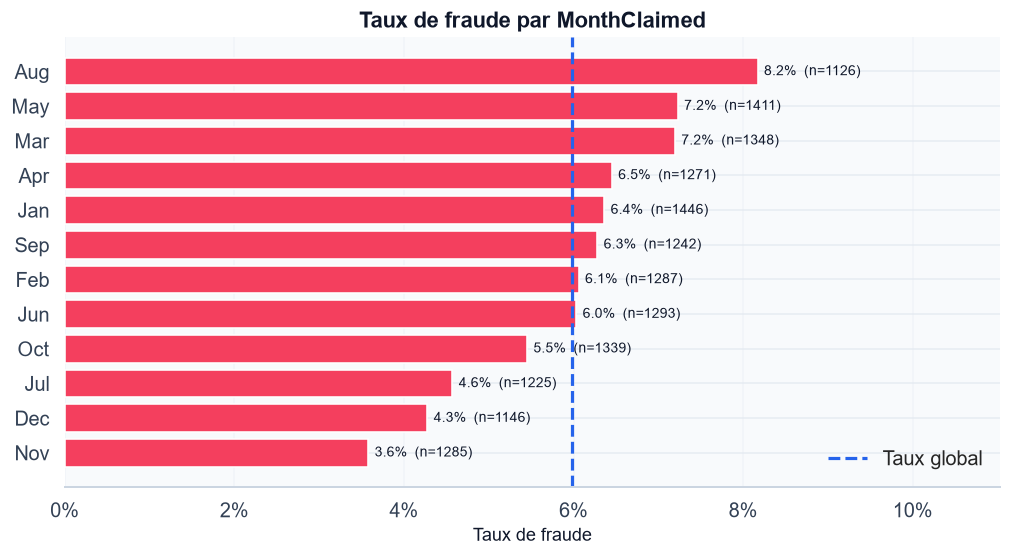

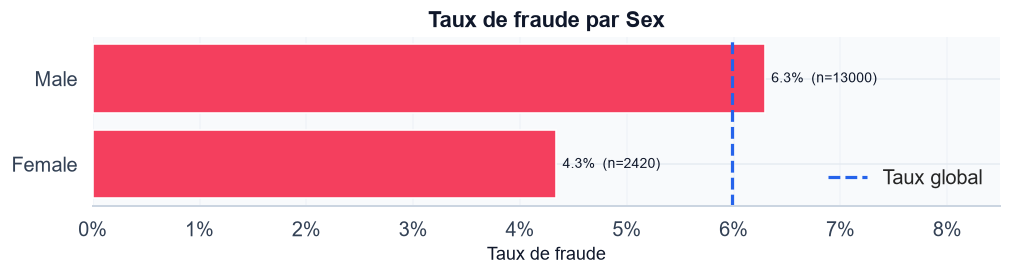

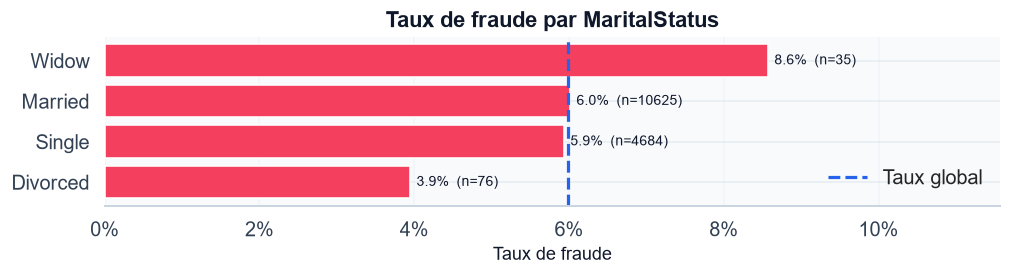

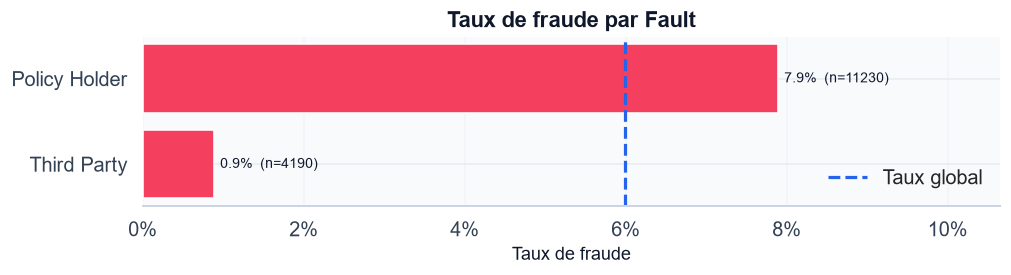

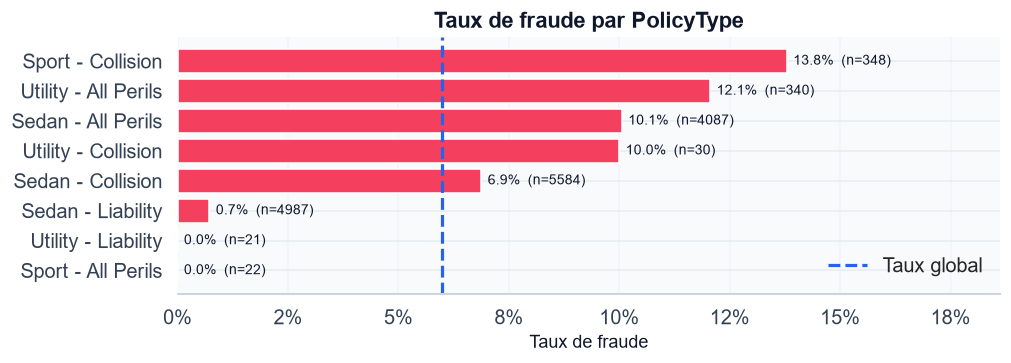

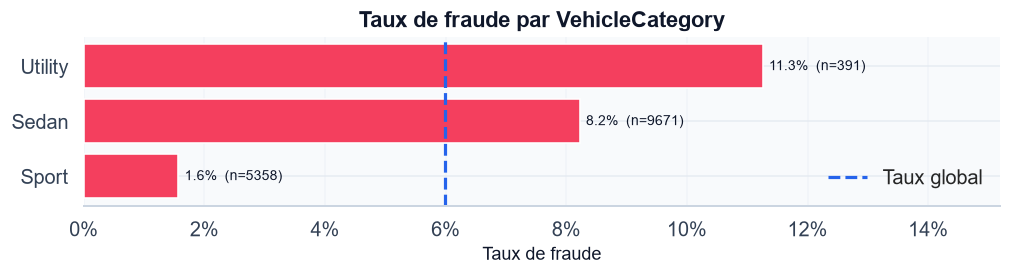

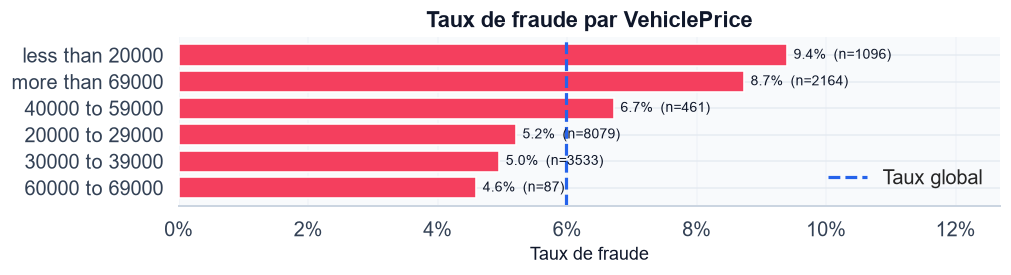

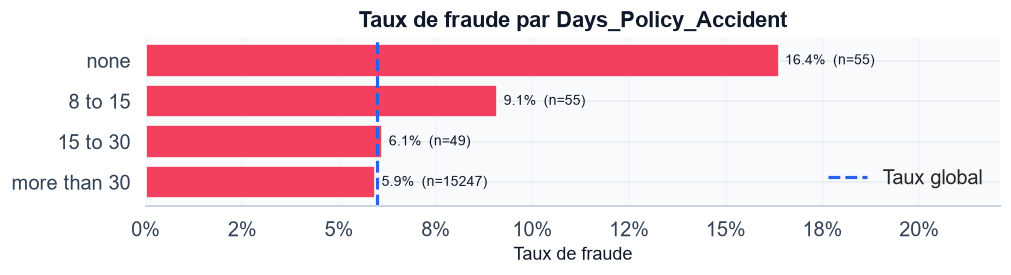

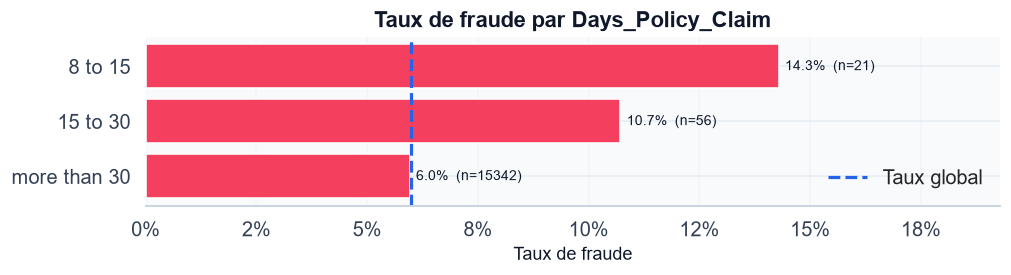

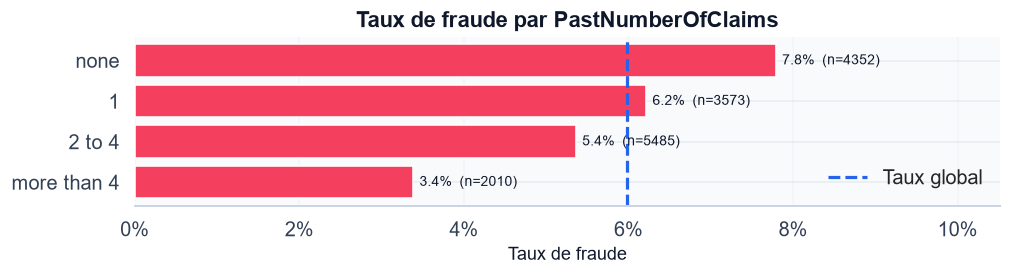

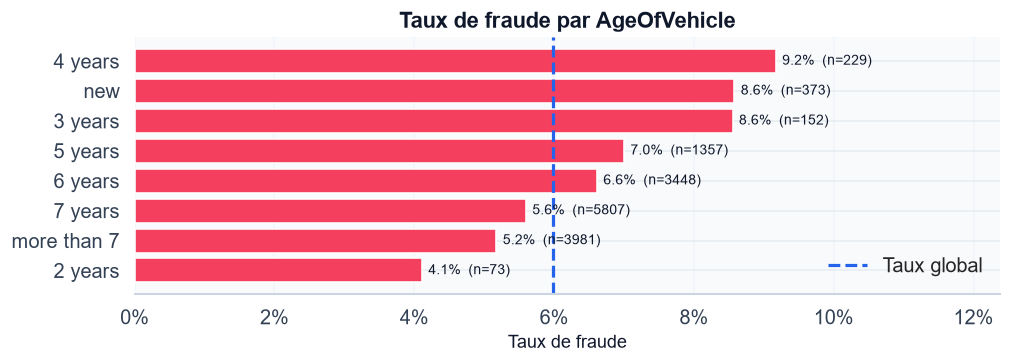

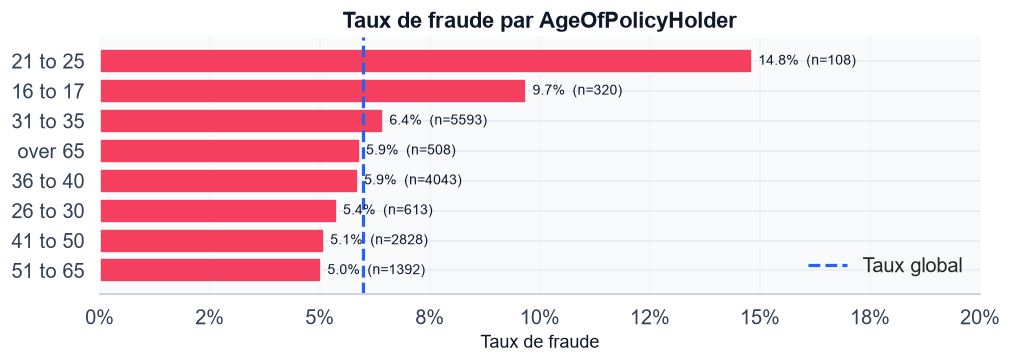

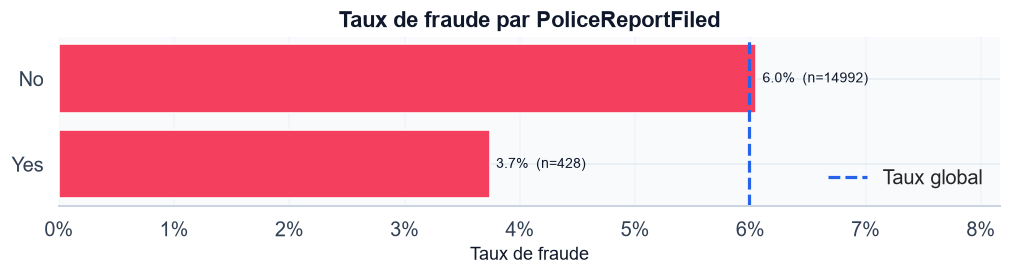

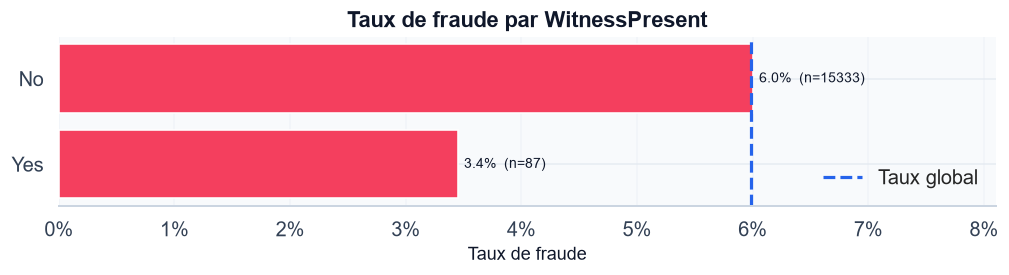

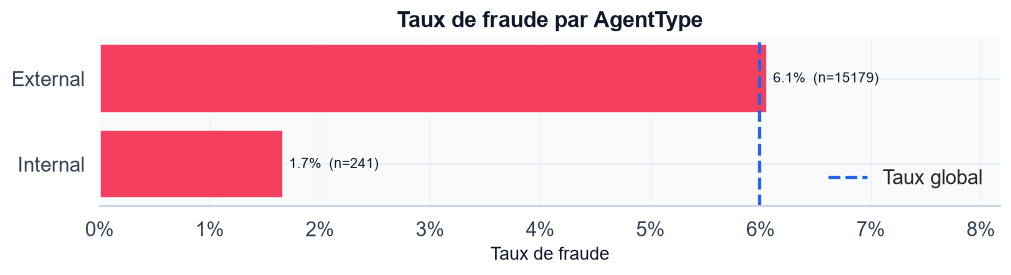

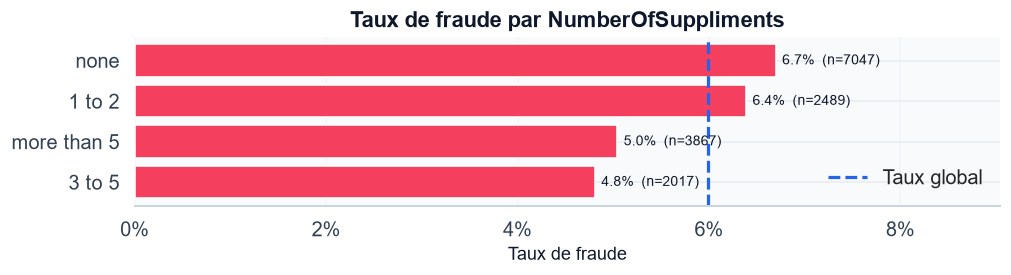

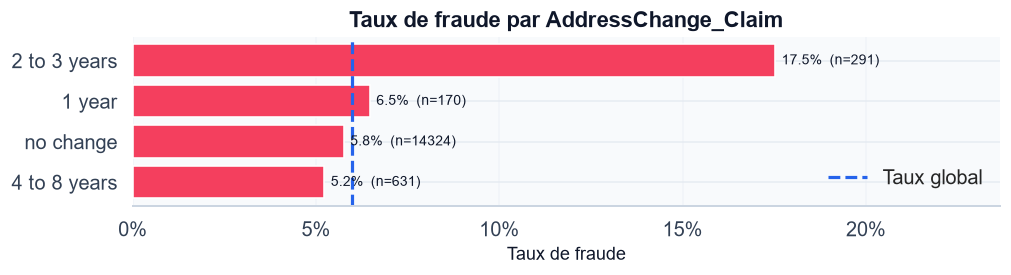

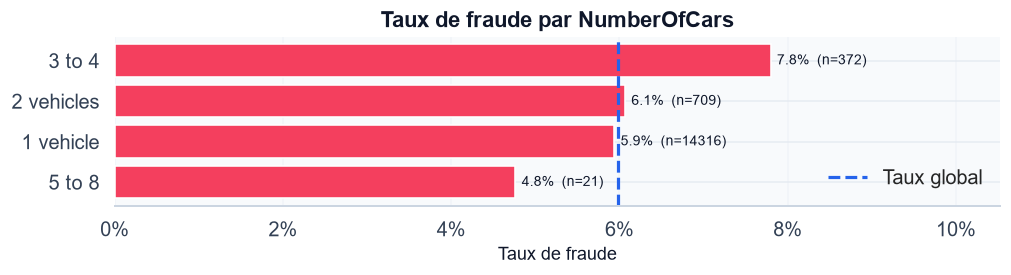

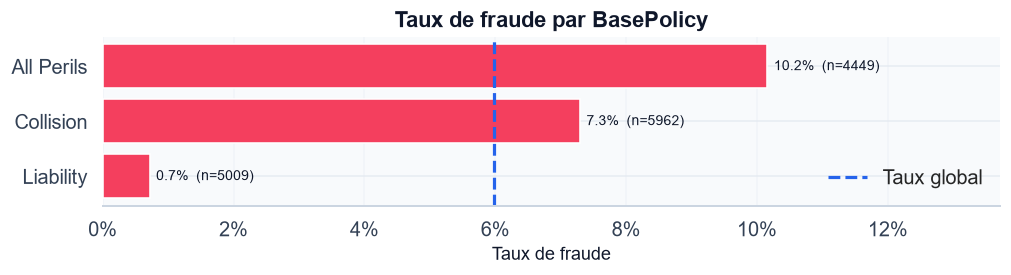

In [10]:
def category_fraud_table(data, col, target=TARGET):
    out = data.groupby(col, dropna=False)[target].agg(['count', 'sum', 'mean']).reset_index()
    out.columns = [col, 'effectif', 'fraudes', 'taux_fraude']
    out['lift'] = out['taux_fraude'] / data[target].mean()
    return out.sort_values('taux_fraude', ascending=False)

category_cols = [c for c in df.columns if c not in numeric_cols + [TARGET, 'PolicyNumber']]
for c in category_cols:
    tab = category_fraud_table(df, c)
    plot_df = (tab.loc[tab['effectif'] >= 20]
               .assign(**{c: tab.loc[tab['effectif'] >= 20, c].astype(str)})
               .sort_values('taux_fraude'))
    fig, ax = plt.subplots(figsize=(9, max(2.6, .42 * len(plot_df))))
    bars = ax.barh(plot_df[c], plot_df['taux_fraude'], color=CORAL)
    labels = [f'{r:.1%}  (n={n})' for r, n in zip(plot_df['taux_fraude'], plot_df['effectif'])]
    ax.bar_label(bars, labels=labels, padding=4, fontsize=9, color=NAVY)
    ax.axvline(df[TARGET].mean(), color=BLUE, linestyle='--', linewidth=2, label='Taux global')
    ax.set(title=f'Taux de fraude par {c}', xlabel='Taux de fraude', ylabel='')
    ax.xaxis.set_major_formatter(lambda x, pos: f'{x:.0%}')
    ax.set_xlim(0, plot_df['taux_fraude'].max() * 1.35)
    sns.despine(left=True)
    ax.grid(axis='x', alpha=.3)
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

### Interprétation - variables catégorielles et ordinales

Les écarts les plus robustes sont : `Fault` (**7,9 %** de fraude pour l'assuré responsable contre **0,9 %** pour un tiers), `BasePolicy` (**10,2 %** pour All Perils contre **0,7 %** pour Liability), `VehicleCategory` (**11,3 %** pour Utility contre **1,6 %** pour Sport) et `AccidentArea` (**8,3 %** en zone rurale contre **5,7 %** en zone urbaine).

L'absence de sinistre antérieur atteint 7,8 %, puis le taux décroît jusqu'à 3,4 % au-delà de quatre sinistres. `VehiclePrice` est non monotone : les prix extrêmes ont les taux les plus élevés, donc un encodage ordinal linéaire serait discutable.

Les taux spectaculaires calculés sur moins de 50 observations ne constituent pas une preuve. Par exemple, 75 % après un changement d'adresse sous six mois repose sur seulement quatre dossiers; son intervalle de confiance est extrêmement large.

*Les modalités portant moins de 20 dossiers (ex. `Mecedes`, `Jaguar`, `Porche`) sont omises des graphiques : leur taux de fraude n'est pas interprétable, mais elles restent présentes dans les données pour la modélisation.*

## 6. Cohérence temporelle et variables cycliques

Les mois et jours ne doivent pas être encodés comme de simples entiers linéaires. On inspecte aussi le délai approximatif entre accident et déclaration.

Modalités non reconnues des mois : [{'Month': 'Jul', 'MonthClaimed': '0'}]
Modalités non reconnues des jours : [{'DayOfWeek': 'Monday', 'DayOfWeekClaimed': '0'}]


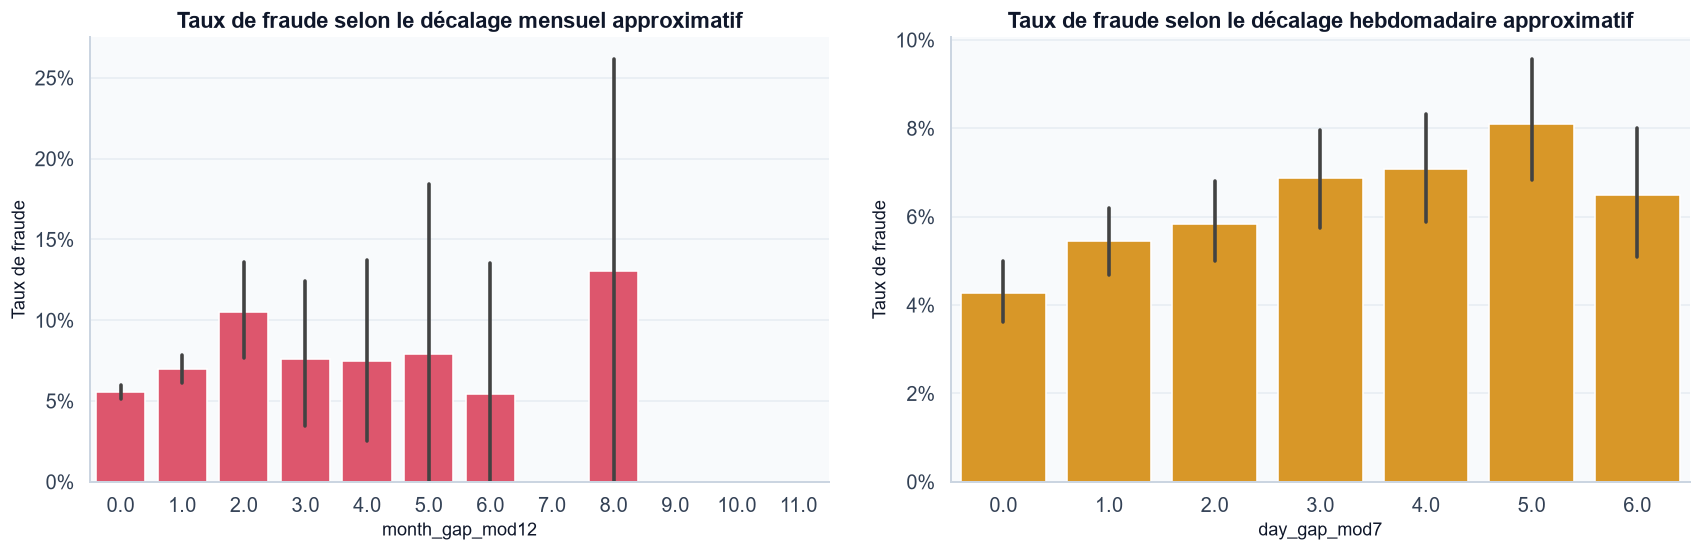

In [11]:
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
month_num = {m: i+1 for i, m in enumerate(month_order)}
day_num = {d: i for i, d in enumerate(day_order)}

temporal = df.copy()
temporal['month_accident_num'] = temporal['Month'].map(month_num)
temporal['month_claim_num'] = temporal['MonthClaimed'].map(month_num)
temporal['day_accident_num'] = temporal['DayOfWeek'].map(day_num)
temporal['day_claim_num'] = temporal['DayOfWeekClaimed'].map(day_num)
temporal['month_gap_mod12'] = (temporal['month_claim_num'] - temporal['month_accident_num']) % 12
temporal['day_gap_mod7'] = (temporal['day_claim_num'] - temporal['day_accident_num']) % 7

print('Modalités non reconnues des mois :', df.loc[temporal['month_accident_num'].isna() | temporal['month_claim_num'].isna(), ['Month','MonthClaimed']].drop_duplicates().to_dict('records'))
print('Modalités non reconnues des jours :', df.loc[temporal['day_accident_num'].isna() | temporal['day_claim_num'].isna(), ['DayOfWeek','DayOfWeekClaimed']].drop_duplicates().to_dict('records'))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=temporal, x='month_gap_mod12', y=TARGET, color=CORAL, ax=axes[0])
sns.barplot(data=temporal, x='day_gap_mod7', y=TARGET, color=GOLD, ax=axes[1])
axes[0].set(title='Taux de fraude selon le décalage mensuel approximatif', ylabel='Taux de fraude')
axes[1].set(title='Taux de fraude selon le décalage hebdomadaire approximatif', ylabel='Taux de fraude')
for ax in axes:
    ax.yaxis.set_major_formatter(lambda x, pos: f'{x:.0%}')
    ax.spines[['top','right']].set_visible(False)
plt.tight_layout(w_pad=2); plt.show()

### Interprétation - dimensions temporelles

Les mois d'accident et de déclaration sont fortement liés, ce qui correspond à des déclarations généralement rapides. Mois et jours sont cycliques : décembre est voisin de janvier et dimanche de lundi. Ils seront représentés par sinus/cosinus, avec des délais modulo 12 et modulo 7. L'unique code `0` ne doit pas être traité comme une date réelle.

## 7. Associations et redondances entre variables

Pearson/Spearman est utilisé pour les numériques. Le V de Cramér mesure l'association entre variables catégorielles, avec correction de biais. Une association élevée ne signifie pas causalité, mais signale une redondance potentielle pour l'encodage.

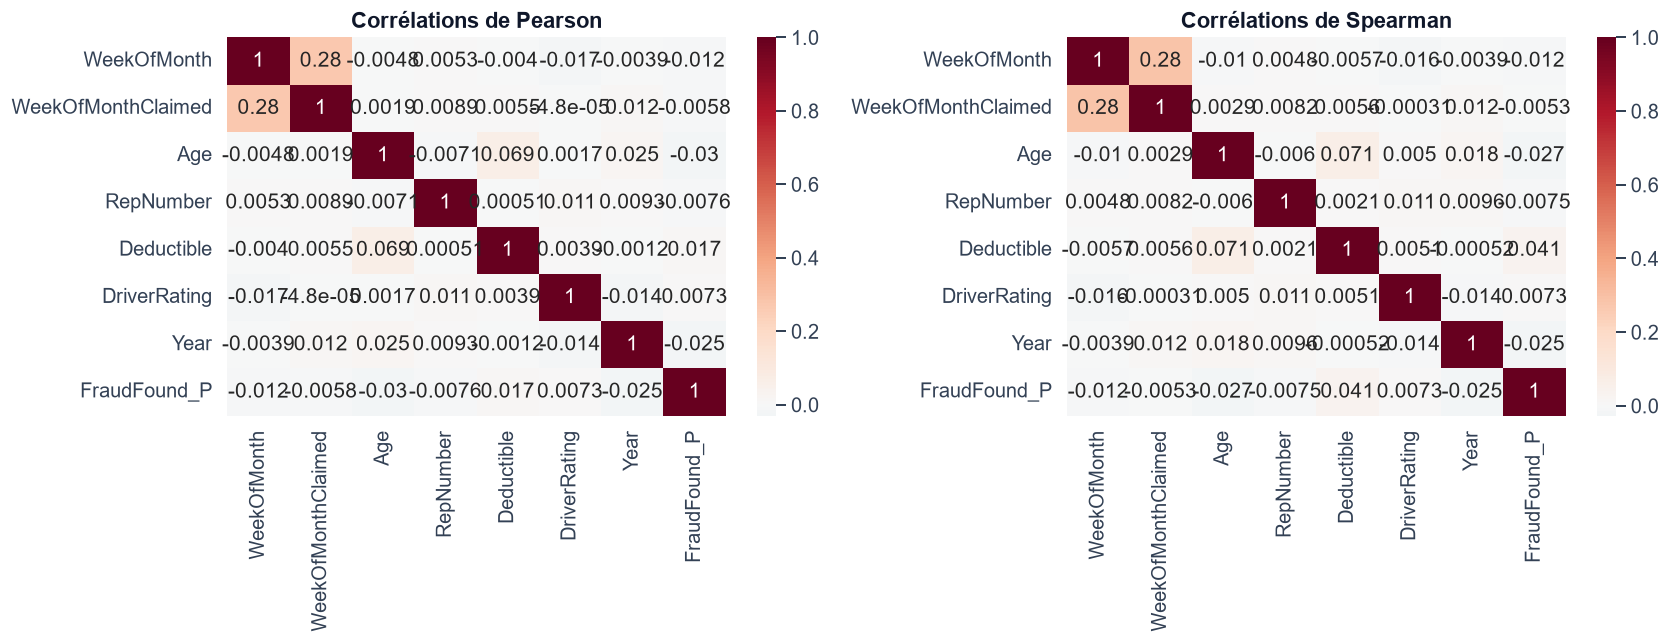

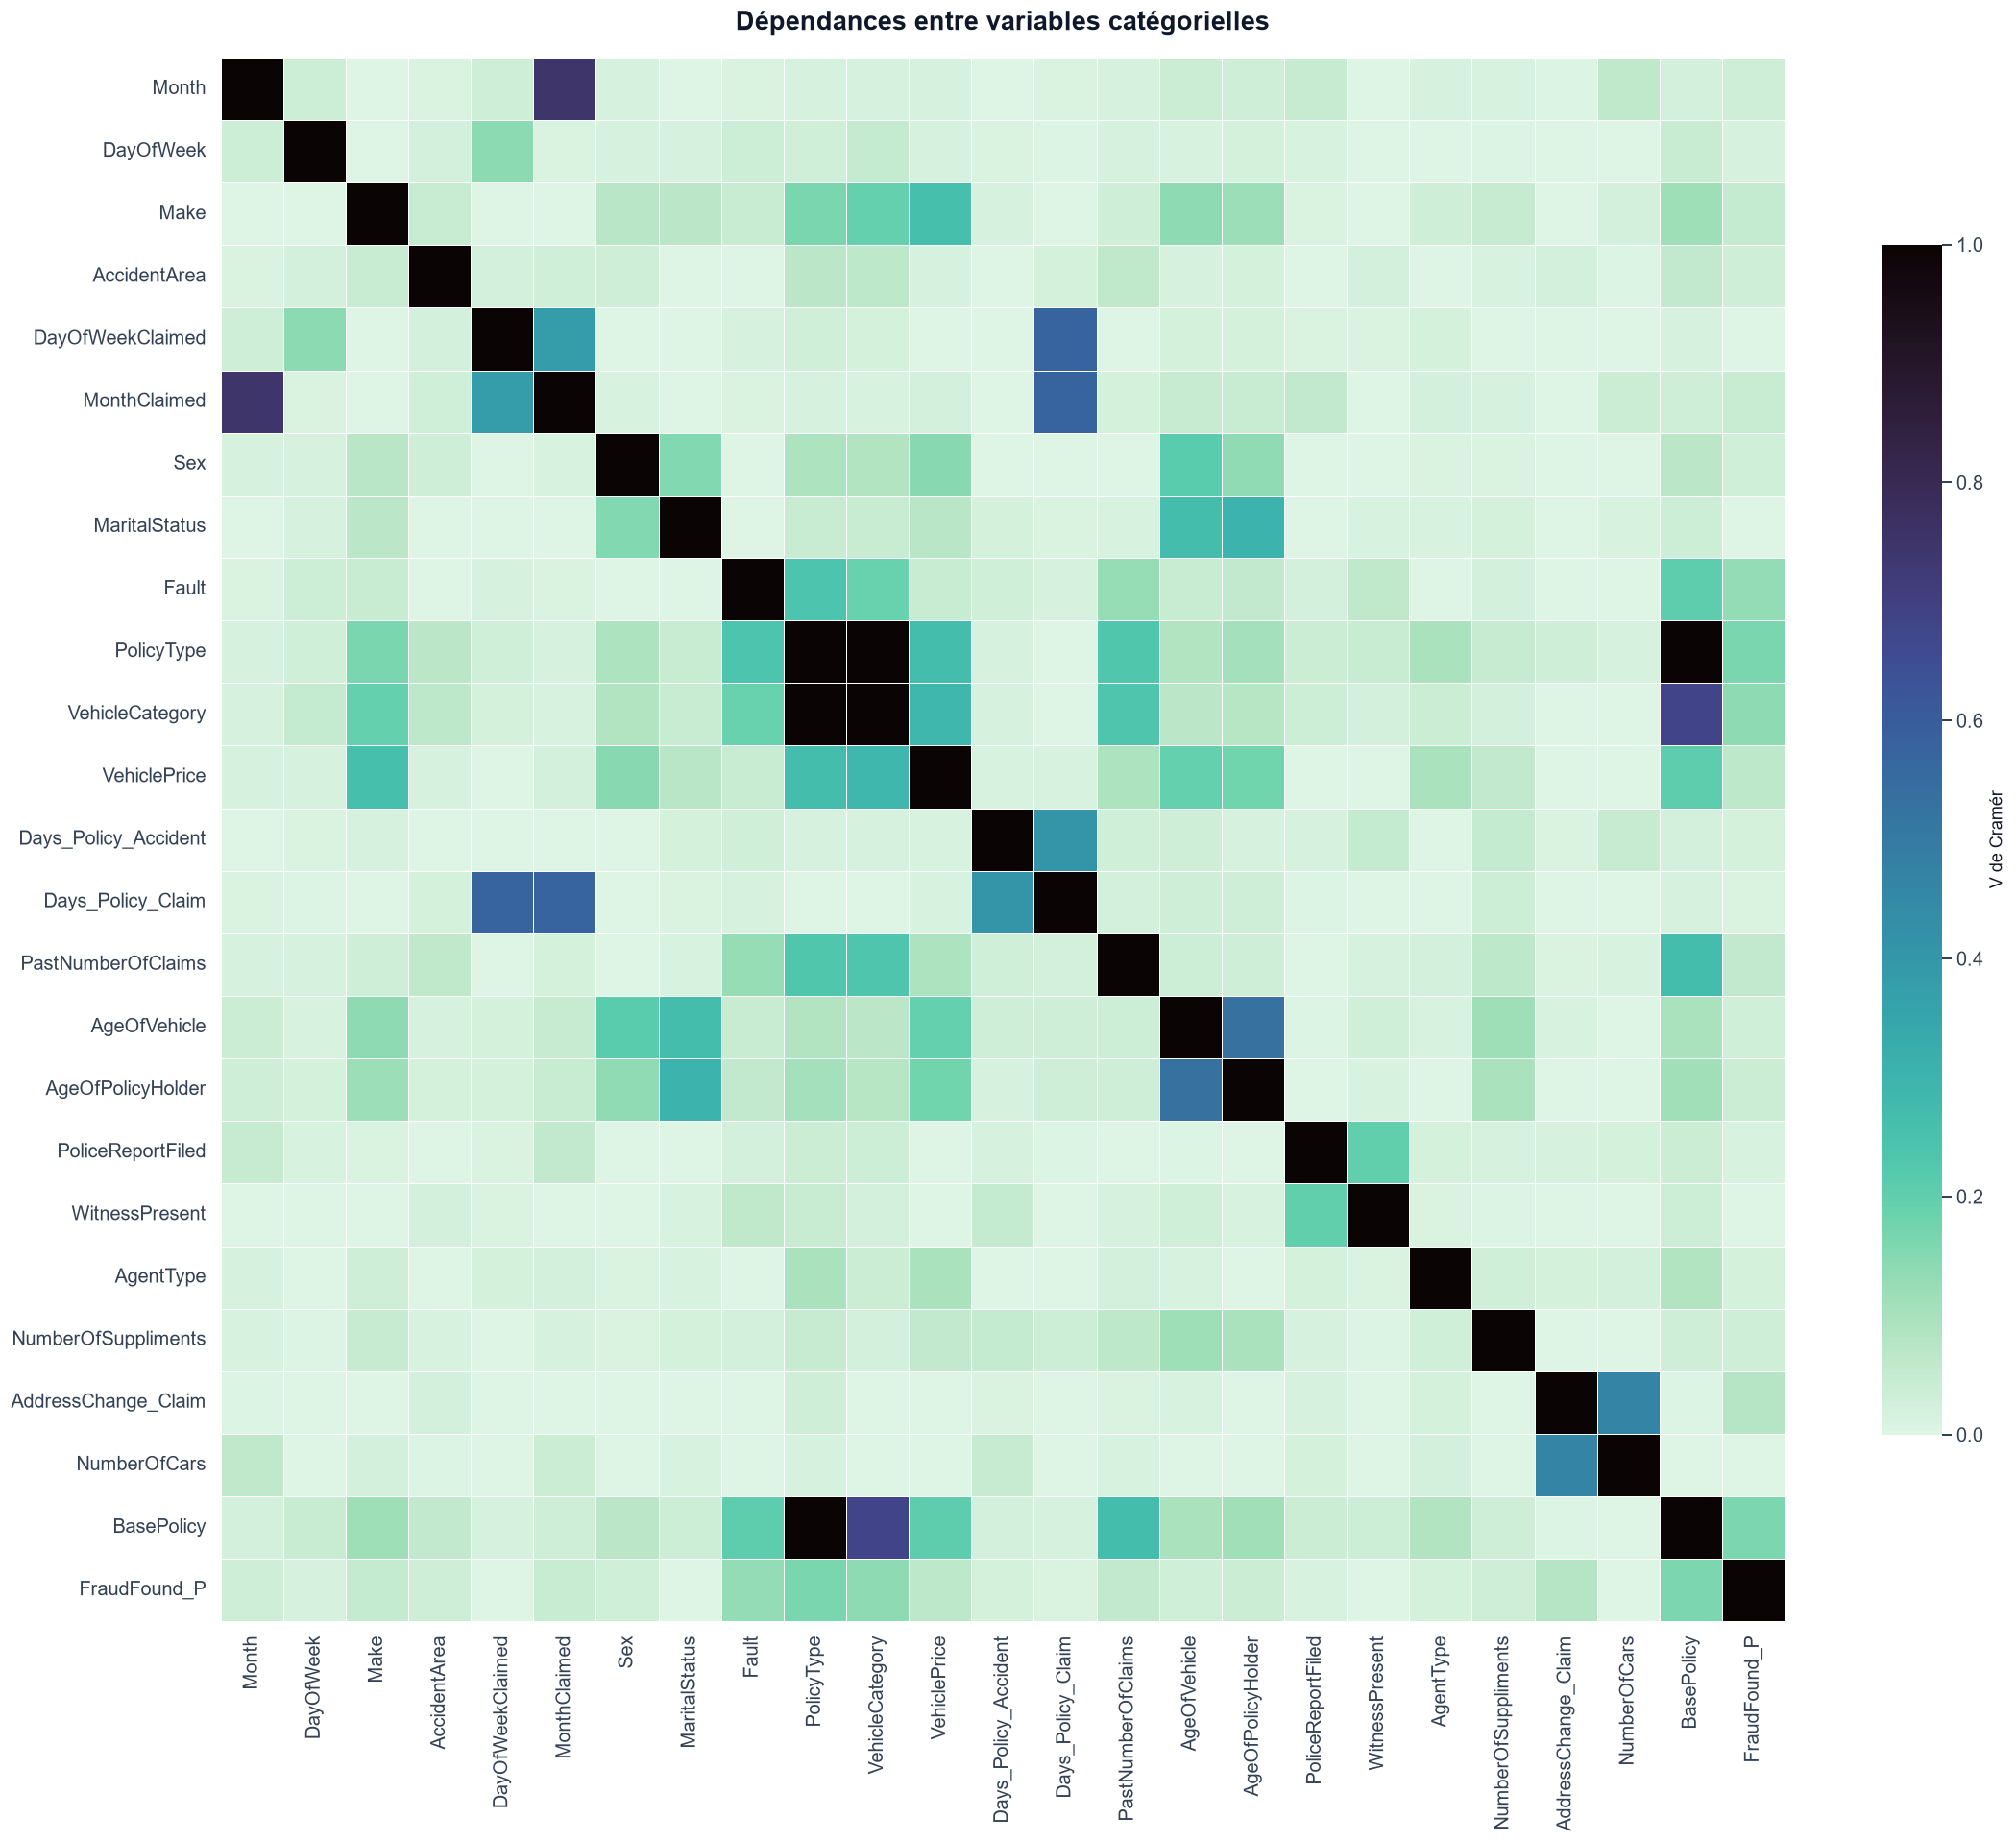

cramers_v
PolicyType           VehicleCategory         1.000
                     BasePolicy              1.000
Month                MonthClaimed            0.747
VehicleCategory      BasePolicy              0.681
DayOfWeekClaimed     Days_Policy_Claim       0.577
MonthClaimed         Days_Policy_Claim       0.577
AgeOfVehicle         AgeOfPolicyHolder       0.534
AddressChange_Claim  NumberOfCars            0.468
Days_Policy_Accident Days_Policy_Claim       0.407
DayOfWeekClaimed     MonthClaimed            0.380
MaritalStatus        AgeOfPolicyHolder       0.304
VehicleCategory      VehiclePrice            0.286
PolicyType           VehiclePrice            0.268
PastNumberOfClaims   BasePolicy              0.267
MaritalStatus        AgeOfVehicle            0.266
Make                 VehiclePrice            0.260
Fault                PolicyType              0.240
VehicleCategory      PastNumberOfClaims      0.237
PolicyType           PastNumberOfClaims      0.232
Sex                  AgeOfVehicle            0.212
Fault                BasePolicy              0.207
VehiclePrice         BasePolicy              0.204
PoliceReportFiled    WitnessPresent          0.198
VehiclePrice         AgeOfVehicle            0.192
Make                 VehicleCategory         0.192

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))
sns.heatmap(df[numeric_cols + [TARGET]].corr(method='pearson'), annot=True, cmap='RdBu_r', center=0, ax=axes[0])
axes[0].set_title('Corrélations de Pearson')
sns.heatmap(df[numeric_cols + [TARGET]].corr(method='spearman'), annot=True, cmap='RdBu_r', center=0, ax=axes[1])
axes[1].set_title('Corrélations de Spearman')
plt.tight_layout(); plt.show()

def cramers_v(x, y):
    table = pd.crosstab(x, y)
    if min(table.shape) < 2:
        return 0.0
    chi2 = chi2_contingency(table, correction=False)[0]
    n = table.to_numpy().sum()
    phi2 = chi2 / n
    r, k = table.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / max(1e-12, min(kcorr-1, rcorr-1)))

assoc_cols = category_cols + [TARGET]
cramer = pd.DataFrame(np.eye(len(assoc_cols)), index=assoc_cols, columns=assoc_cols)
for i, c1 in enumerate(assoc_cols):
    for c2 in assoc_cols[i+1:]:
        cramer.loc[c1, c2] = cramer.loc[c2, c1] = cramers_v(df[c1], df[c2])

plt.figure(figsize=(20, 17))
sns.heatmap(cramer, cmap='mako_r', vmin=0, vmax=1, square=True, linewidths=.35, linecolor='white', cbar_kws={'shrink': .72, 'label': "V de Cramér"})
plt.title('Dépendances entre variables catégorielles', pad=18, fontsize=17, fontweight='bold')
plt.tight_layout(); plt.show()

pairs = cramer.where(np.triu(np.ones(cramer.shape), 1).astype(bool)).stack().sort_values(ascending=False)
display(pairs.rename('cramers_v').head(25).to_frame())

### Interprétation - associations et redondances

- `PolicyType` est une combinaison déterministe de `VehicleCategory` et `BasePolicy` (**V de Cramér = 1**). Conserver les trois après one-hot surreprésenterait la même information pour Isolation Forest.
- Il faudra comparer `PolicyType` seule à `VehicleCategory + BasePolicy`.
- `Month` et `MonthClaimed` sont fortement associés; une variable de délai est plus interprétable que deux encodages indépendants seuls.
- Les associations entre âge du véhicule, âge du titulaire et statut matrimonial décrivent une structure de portefeuille, pas nécessairement un mécanisme causal de fraude.

## 8. Pouvoir univarié indicatif par information mutuelle

Ce classement est exploratoire. Il ne justifie pas une sélection définitive et doit être recalculé uniquement sur le train dans le pipeline final.

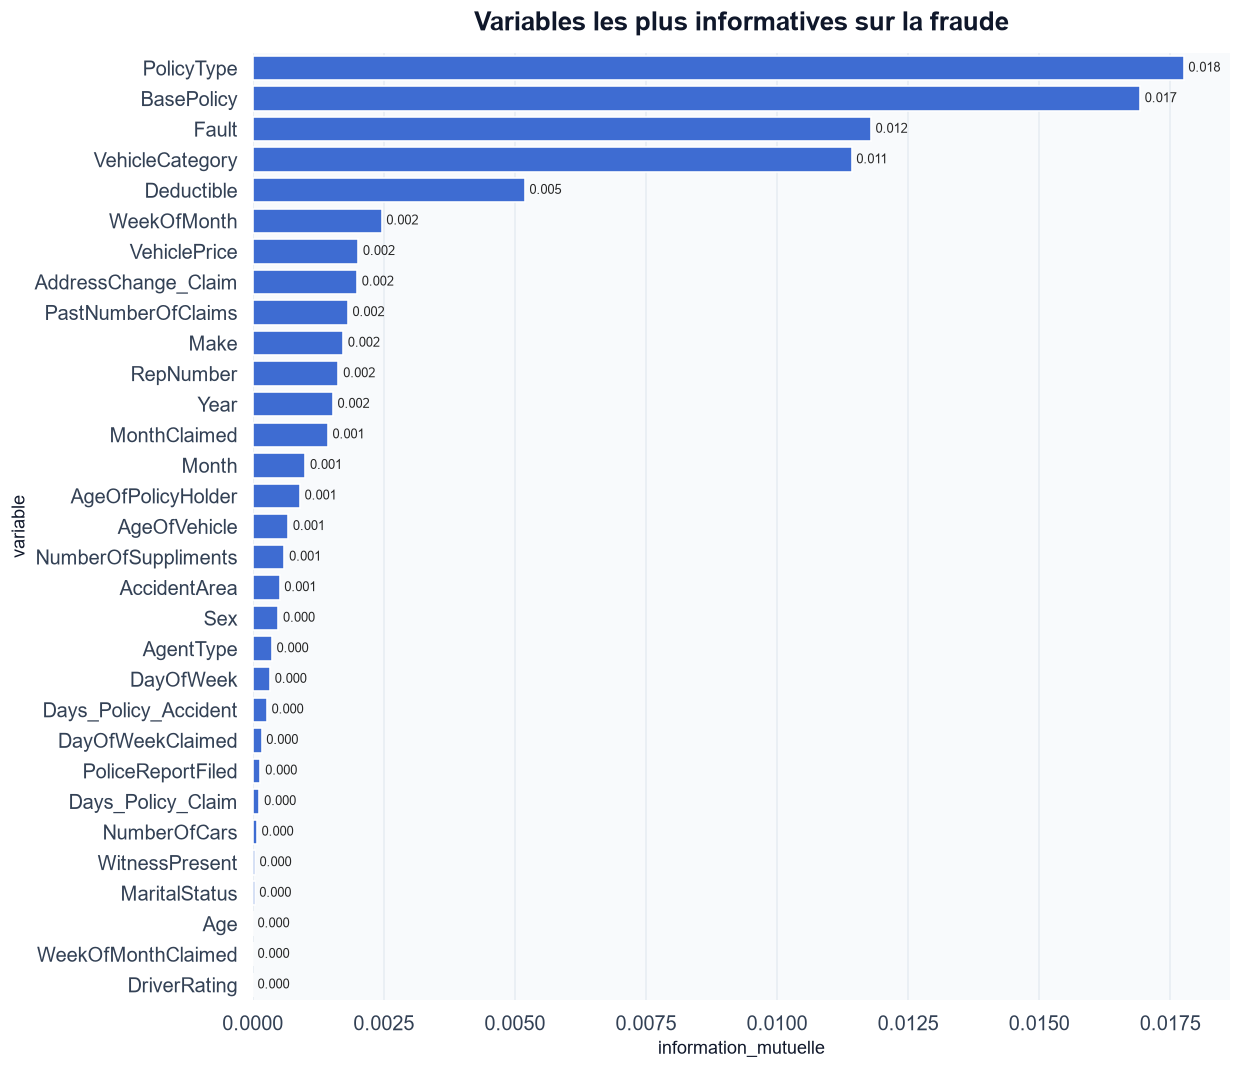

In [13]:
X_mi = df.drop(columns=[TARGET, 'PolicyNumber']).copy()
for c in X_mi.select_dtypes(exclude='number'):
    X_mi[c] = pd.factorize(X_mi[c], sort=True)[0]
discrete_mask = [c not in numeric_cols for c in X_mi.columns]
mi = mutual_info_classif(X_mi, df[TARGET], discrete_features=discrete_mask, random_state=RANDOM_STATE)
mi_table = pd.DataFrame({'variable': X_mi.columns, 'information_mutuelle': mi}).sort_values('information_mutuelle', ascending=False)

plt.figure(figsize=(11, 9.5))
ax = sns.barplot(data=mi_table, y='variable', x='information_mutuelle', color=BLUE)
ax.bar_label(ax.containers[0], fmt='%.3f', padding=3, fontsize=8)
plt.title('Variables les plus informatives sur la fraude', pad=14, fontsize=16, fontweight='bold')
sns.despine(left=True, bottom=True)
plt.grid(axis='y', visible=False)
plt.tight_layout(); plt.show()

### Interprétation - information mutuelle

`PolicyType`, `BasePolicy`, `Fault` et `VehicleCategory` concentrent le signal univarié principal. Les valeurs restent toutefois faibles : la fraude ne suit pas une règle simple fondée sur une seule variable. Ce classement est exploratoire et devra être recalculé uniquement sur le train avant toute sélection.

## 9. Interactions métier prioritaires

On explore quelques croisements plausibles sans multiplier artificiellement les tests : responsabilité × police, catégorie × prix, agent × zone et police × âge du véhicule.

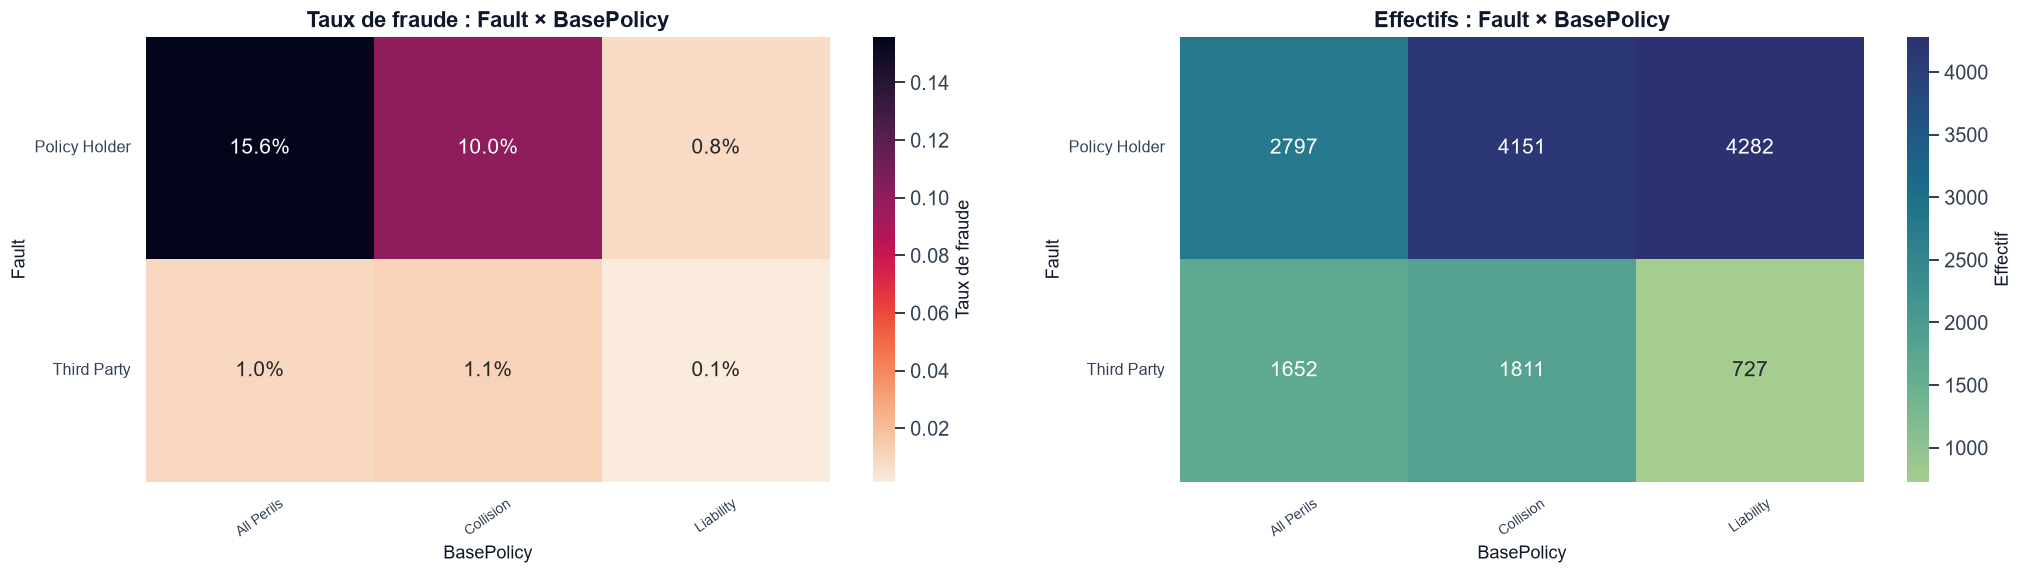

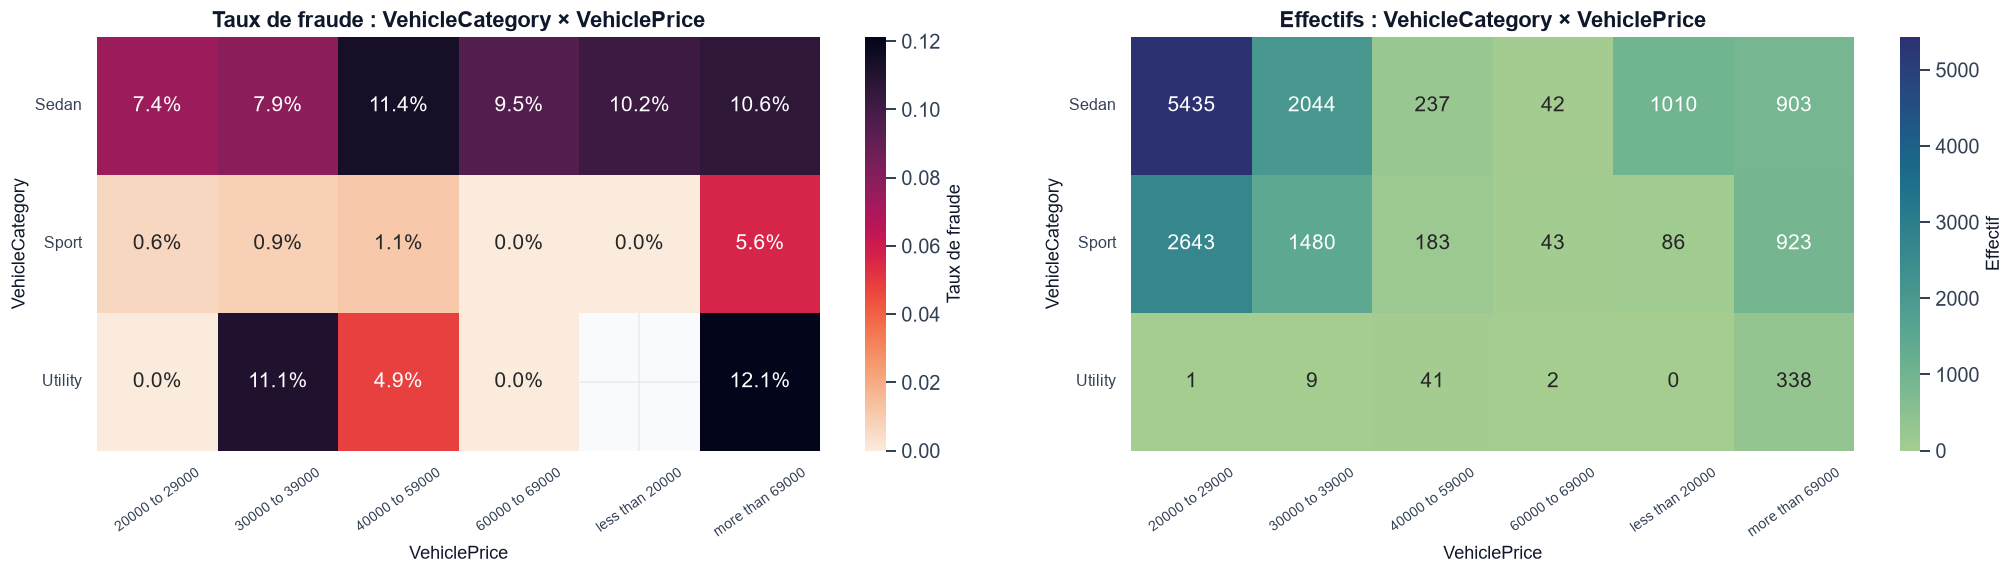

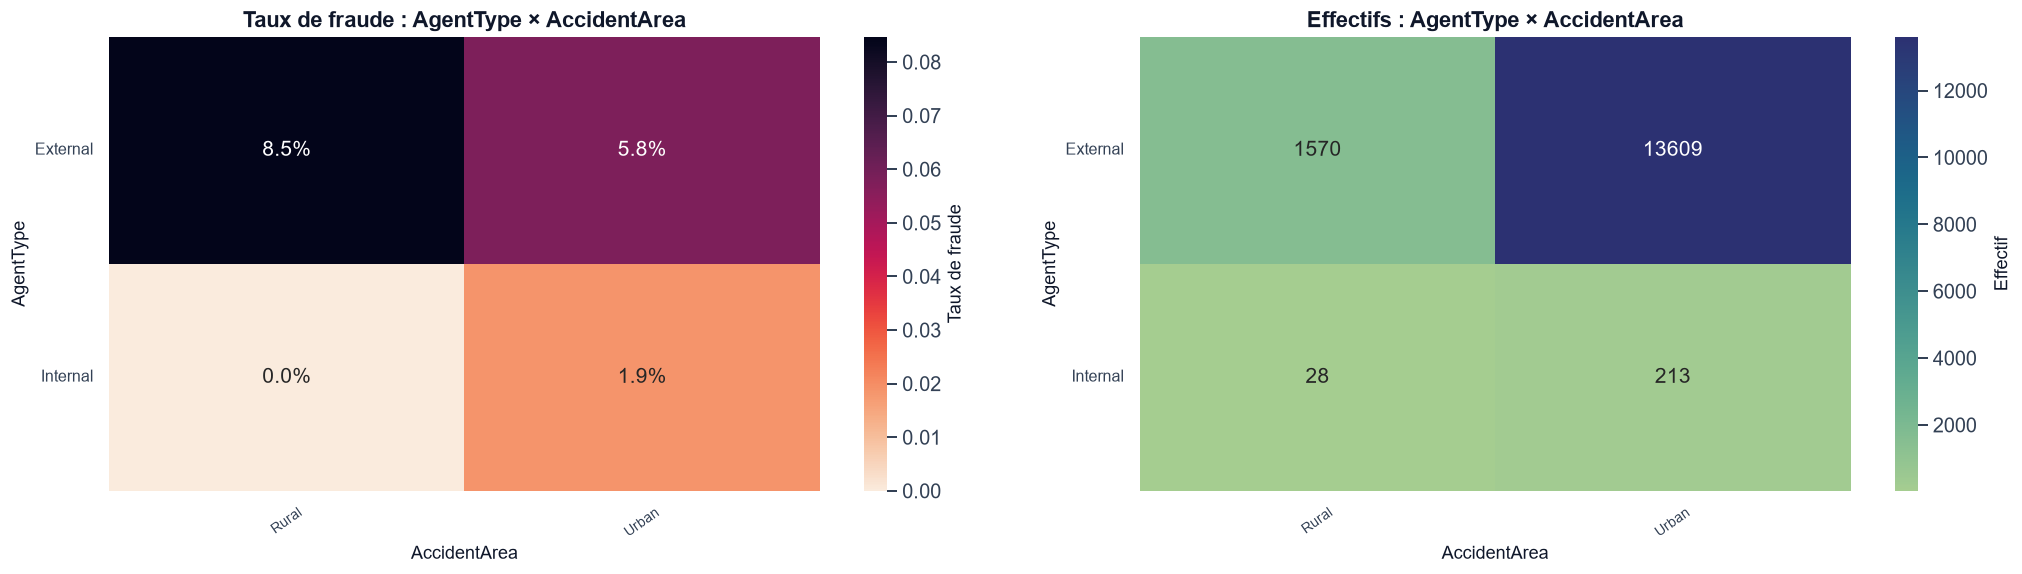

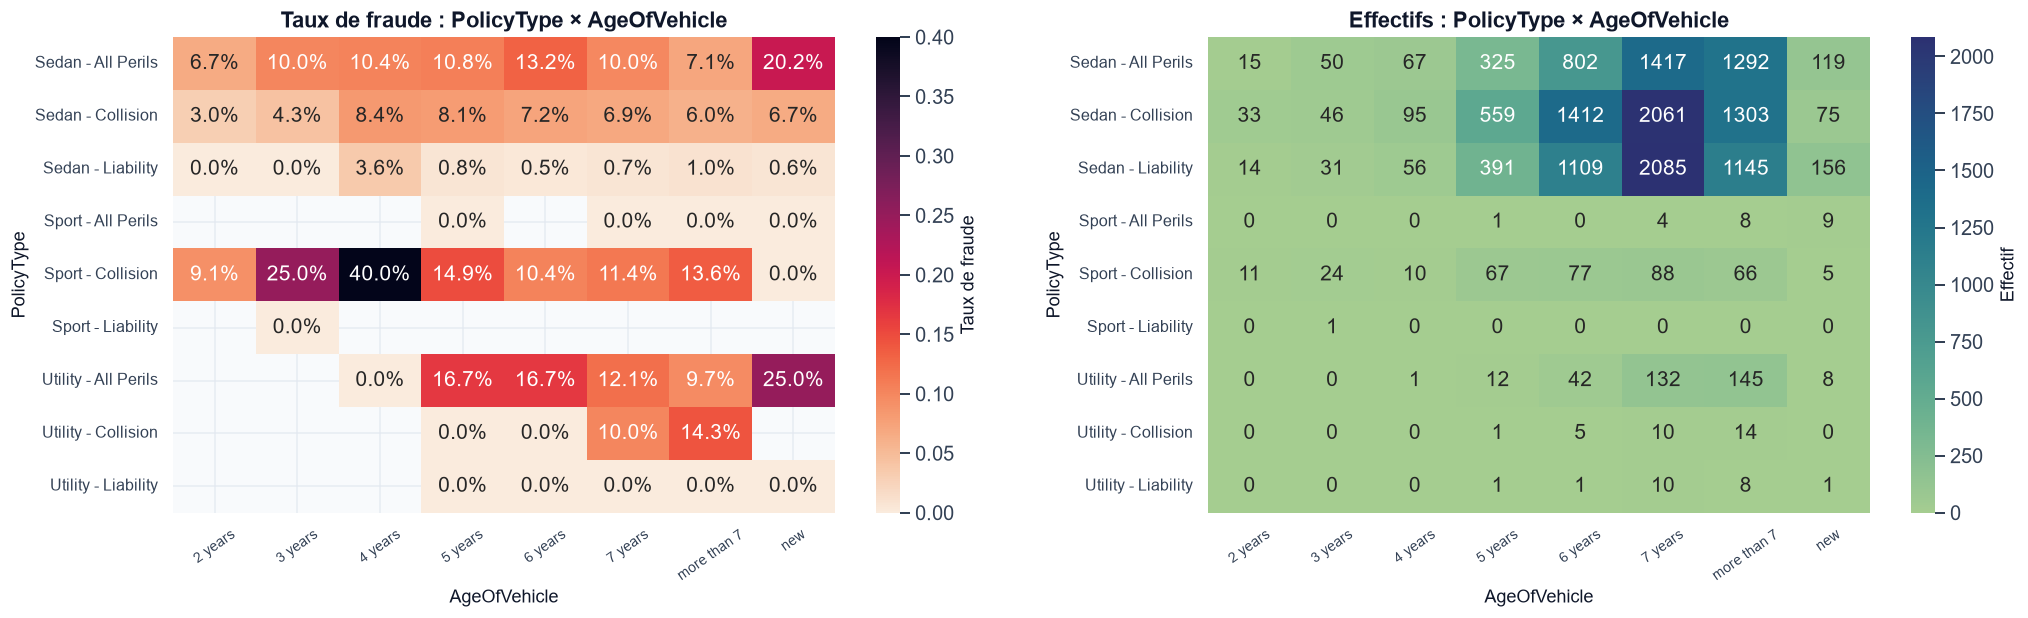

In [14]:
interaction_pairs = [
    ('Fault', 'BasePolicy'),
    ('VehicleCategory', 'VehiclePrice'),
    ('AgentType', 'AccidentArea'),
    ('PolicyType', 'AgeOfVehicle'),
]
for a, b in interaction_pairs:
    rate = pd.pivot_table(df, values=TARGET, index=a, columns=b, aggfunc='mean')
    count = pd.crosstab(df[a], df[b])
    fig, axes = plt.subplots(1, 2, figsize=(18, max(5.2, .62 * len(rate))))
    sns.heatmap(rate, annot=True, fmt='.1%', cmap='rocket_r', ax=axes[0], cbar_kws={'label': 'Taux de fraude'})
    axes[0].set_title(f'Taux de fraude : {a} × {b}')
    sns.heatmap(count, annot=True, fmt='g', cmap='crest', ax=axes[1], cbar_kws={'label': 'Effectif'})
    axes[1].set_title(f'Effectifs : {a} × {b}')
    for ax in axes:
        ax.tick_params(axis='x', rotation=35, labelsize=9)
        ax.tick_params(axis='y', rotation=0, labelsize=10)
    plt.tight_layout(w_pad=2.5); plt.show()

### Interprétation - interactions métier

Les cartes montrent que les combinaisons responsabilité × garantie et catégorie × prix sont plus informatives que certaines variables isolées. Chaque carte de taux doit être lue avec sa carte d'effectifs : une cellule très rouge contenant quelques dossiers n'est pas robuste. Les interactions candidates devront être validées par ablation hors échantillon.

## 10. Valeurs atypiques et préparation à Isolation Forest

Isolation Forest est sensible à la représentation. Cette section repère les variables numériques extrêmes et documente les colonnes à exclure, transformer ou encoder.

In [15]:
outlier_rows = []
for c in numeric_cols:
    q1, q3 = df[c].quantile([.25, .75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    mask = (df[c] < lo) | (df[c] > hi)
    outlier_rows.append({'variable': c, 'borne_basse': lo, 'borne_haute': hi, 'n_hors_IQR': int(mask.sum()), 'pct_hors_IQR': 100*mask.mean()})
display(pd.DataFrame(outlier_rows))

constant_cols = quality.index[quality['n_unique'] <= 1].tolist()
quasi_constant_cols = [c for c in df.columns if df[c].value_counts(normalize=True, dropna=False).iloc[0] >= .95]
high_cardinality_cols = quality.index[quality['pct_unique'] >= 90].tolist()
print('Constantes :', constant_cols)
print('Quasi-constantes (modalité dominante ≥ 95 %) :', quasi_constant_cols)
print('Très haute cardinalité (≥ 90 % uniques) :', high_cardinality_cols)

# Empreinte dimensionnelle d'un one-hot intégral des variables catégorielles
cardinality = df[category_cols].nunique().sort_values(ascending=False)
print(f"Colonnes après one-hot intégral des {len(category_cols)} variables catégorielles : "
      f"{cardinality.sum()} indicatrices (+{len(numeric_cols)} numériques) pour {len(df):,} lignes")
display(cardinality.head(8).to_frame('n_modalites'))

,variable,borne_basse,borne_haute,n_hors_IQR,pct_hors_IQR
0,WeekOfMonth,-1.000,7.000,0,0.000
1,WeekOfMonthClaimed,-1.000,7.000,0,0.000
2,Age,5.500,73.500,547,3.547
3,RepNumber,-5.500,22.500,0,0.000
4,Deductible,400.000,400.000,582,3.774
5,DriverRating,-2.000,6.000,0,0.000
6,Year,"1,991.000","1,999.000",0,0.000


Constantes : []
Quasi-constantes (modalité dominante ≥ 95 %) : ['Deductible', 'Days_Policy_Accident', 'Days_Policy_Claim', 'PoliceReportFiled', 'WitnessPresent', 'AgentType']
Très haute cardinalité (≥ 90 % uniques) : ['PolicyNumber']
Colonnes après one-hot intégral des 24 variables catégorielles : 140 indicatrices (+7 numériques) pour 15,420 lignes


,n_modalites
Make,19
MonthClaimed,13
Month,12
PolicyType,9
AgeOfPolicyHolder,9
AgeOfVehicle,8
DayOfWeekClaimed,8
DayOfWeek,7


### Interprétation - préparation à Isolation Forest

- Exclure `PolicyNumber` et séparer `FraudFound_P` avant toute transformation.
- Évaluer les variables quasi constantes par ablation plutôt que les supprimer automatiquement.
- Comparer one-hot, regroupement rare, encodage fréquentiel et mappings ordinaux documentés.
- Apprendre tous les seuils, regroupements et fréquences uniquement sur le train.
- Le scaling sera nécessaire pour comparer loyalement LOF et One-Class SVM, même s'il n'est pas indispensable à Isolation Forest.
- Compléter le split stratifié par une validation temporelle par année et tester plusieurs graines aléatoires.
- Parmi les quasi-constantes, `Days_Policy_Accident` et `Days_Policy_Claim` (modalité dominante ≥ 98,9 %) portent pourtant un signal de fraude connu en assurance (sinistre déclaré peu après la souscription) : lift de 2,7 pour `none` et 2,4 pour `8 to 15` (section 5). Elles ne doivent donc pas être exclues automatiquement par le seul seuil de quasi-constance.
- Un one-hot intégral des 24 variables catégorielles porterait la dimension à 147 colonnes (140 indicatrices + 7 numériques) pour 15 420 lignes, avec des modalités sous 1 % concentrées sur `Make` (11 marques sur 19). Cela renforce l'intérêt de comparer one-hot et encodage fréquentiel plutôt que d'imposer le premier par défaut.

## 11. Synthèse automatique et décisions de feature engineering

In [16]:
fraud_rate = df[TARGET].mean()
print(f'''SYNTHÈSE FACTUELLE
- Dimensions : {len(df):,} lignes × {df.shape[1]} colonnes
- Fraudes : {df[TARGET].sum():,} ({fraud_rate:.2%})
- Valeurs manquantes explicites : {df.isna().sum().sum():,}
- Doublons exacts : {df.duplicated().sum():,}
- Identifiant unique à exclure : PolicyNumber
- Variables constantes : {constant_cols or 'aucune'}
- Variables quasi constantes : {quasi_constant_cols or 'aucune'}
- Variables à forte cardinalité : {high_cardinality_cols or 'aucune'}
''')

feature_plan = pd.DataFrame([
    ['PolicyNumber', 'Exclure', 'Identifiant unique sans sens prédictif généralisable'],
    [TARGET, 'Séparer de X', 'Étiquette réservée à l’évaluation, sinon fuite de cible'],
    ['Month, MonthClaimed', 'Encodage cyclique sin/cos + délai approximatif', 'Janvier est voisin de décembre'],
    ['DayOfWeek, DayOfWeekClaimed', 'Encodage cyclique sin/cos + délai modulo 7', 'Structure hebdomadaire cyclique'],
    ['Variables ordinales textuelles', 'Mapping ordinal documenté + indicateur classe ouverte', 'Préserver l’ordre sans inventer une distance parfaite'],
    ['Variables nominales', 'One-hot / frequency encoding à comparer', 'Isolation Forest standard exige une représentation numérique'],
    ['Modalités rares', 'Regrouper selon seuil appris sur train', 'Limiter dimensions et anomalies dues au seul encodage'],
    ['Age', 'Indicateur dédié (Age == 0), sans imputation', 'Convention de saisie liée à AgeOfPolicyHolder == 16-17 ans (section 11), pas une valeur manquante'],
    ['RepNumber, DriverRating', 'Tester comme catégories et comme ordinaux', 'Valeurs numériques mais sens possiblement qualitatif'],
    ['Year', 'Catégorie/période, pas variable continue brute', 'Seulement quelques millésimes'],
], columns=['variables', 'action_proposée', 'justification'])
display(feature_plan)

SYNTHÈSE FACTUELLE
- Dimensions : 15,420 lignes × 33 colonnes
- Fraudes : 923 (5.99%)
- Valeurs manquantes explicites : 0
- Doublons exacts : 0
- Identifiant unique à exclure : PolicyNumber
- Variables constantes : aucune
- Variables quasi constantes : ['Deductible', 'Days_Policy_Accident', 'Days_Policy_Claim', 'PoliceReportFiled', 'WitnessPresent', 'AgentType']
- Variables à forte cardinalité : ['PolicyNumber']



,variables,action_proposée,justification
0,PolicyNumber,Exclure,Identifiant unique sans sens prédictif général...
1,FraudFound_P,Séparer de X,"Étiquette réservée à l’évaluation, sinon fuite..."
2,"Month, MonthClaimed",Encodage cyclique sin/cos + délai approximatif,Janvier est voisin de décembre
3,"DayOfWeek, DayOfWeekClaimed",Encodage cyclique sin/cos + délai modulo 7,Structure hebdomadaire cyclique
4,Variables ordinales textuelles,Mapping ordinal documenté + indicateur classe ...,Préserver l’ordre sans inventer une distance p...
5,Variables nominales,One-hot / frequency encoding à comparer,Isolation Forest standard exige une représenta...
6,Modalités rares,Regrouper selon seuil appris sur train,Limiter dimensions et anomalies dues au seul e...
7,Age,"Indicateur dédié (Age == 0), sans imputation",Convention de saisie liée à AgeOfPolicyHolder ...
8,"RepNumber, DriverRating",Tester comme catégories et comme ordinaux,Valeurs numériques mais sens possiblement qual...
9,Year,"Catégorie/période, pas variable continue brute",Seulement quelques millésimes


### Conclusion avant modélisation

1. Créer une séparation entraînement/test **avant** d'apprendre regroupements, fréquences ou seuils.
2. Ne jamais inclure `FraudFound_P` ni `PolicyNumber` dans Isolation Forest.
3. Construire deux représentations comparables : one-hot et encodage fréquentiel/ordinal raisonné.
4. Tester la sensibilité à `n_estimators`, `max_samples` et au taux de contamination.
5. Évaluer hors échantillon avec ROC-AUC, PR-AUC, précision@k, rappel@k et lift@k.
6. Comparer au minimum à LOF et One-Class SVM, conformément à l'esprit de l'article.
7. Interpréter les dossiers les plus anormaux : une anomalie statistique n'est pas automatiquement une fraude.